In [1]:
import pandas as pd
import yaml
import numpy as np
import geopandas as gpd
import os
from matplotlib import pyplot as plt
import seaborn as sns
from shapely.geometry import Point
from tqdm import tqdm
# matplotlibの日本語フォントの設定
plt.rcParams['font.family'] = 'Hiragino Maru Gothic Pro'

# census_zoneを加工


In [ ]:
gdf = gpd.read_file('../data/raw/ゾーニング/census_zone.geojson')
gdf = gdf[(gdf["CITY_NAME"]=="松山市") & (gdf["R05大ゾーン"] != "松山市28区")]
gdf["area_km2"] = gdf["AREA"] / 10**6  # 面積を平方キロメートルに変換
# geojsonとして保存
output_path = "../data/raw/ゾーニング/census_zone.geojson"
gdf.to_file(output_path, driver="GeoJSON", encoding="utf-8")

In [ ]:
gdf = gpd.read_file('../data/raw/ゾーニング/census_zone.geojson')
gdf["S_NAME"] = gdf["S_NAME"].str.replace("一丁目", "1丁目").str.replace("二丁目", "2丁目").str.replace("三丁目", "3丁目").str.replace("四丁目", "4丁目").str.replace("五丁目", "5丁目").str.replace("六丁目", "6丁目").str.replace("七丁目", "7丁目").str.replace("八丁目", "8丁目").str.replace("九丁目", "9丁目").str.replace("十丁目", "10丁目")

zone_dict = gdf.groupby(["R05大ゾーン"])["S_NAME"].apply(set).apply(list).to_dict()
zone_dict = {f"松山市{i}区": zone_dict[f"松山市{i}区"] for i in range(1, 29) if i not in [25, 26, 28]}
zone_dict = {k: sorted(v) for k, v in zone_dict.items()}

with open('../data/raw/zoning/pt_zone.yaml', 'w') as f:
    yaml.dump(zone_dict, f, allow_unicode=True, sort_keys=False)

choice_dict = {"松山市1区": 0, "松山市2区": 0, "松山市3区": 1, "松山市4区": 2, "松山市5区": 3, "松山市6区": 4, "松山市7区": 5, "松山市8区": 6, "松山市9区": 7, "松山市10区": 8, 
                    "松山市11区": 9, "松山市12区": 10, "松山市13区": 11, "松山市14区": 12, "松山市15区": 13, "松山市16区": 14, "松山市17区": 15, "松山市18区": 16, "松山市19区": 17, "松山市20区": 15, 
                    "松山市21区": 14, "松山市22区": 1, "松山市23区": 0, "松山市24区": 15, "松山市27区": 18, "松山市28区": None}

Lzone_dict = {f"ゾーン{v}": [] for v in range(19)}
for v in range(19):
    for k, val in choice_dict.items():
        if val == v:
            Lzone_dict[f"ゾーン{v}"].extend(zone_dict[k])
Lzone_dict["ゾーン18"] += ["大河内"]
with open('../data/raw/zoning/19_zone.yaml', 'w') as f:
    yaml.dump(Lzone_dict, f, allow_unicode=True, sort_keys=False)

In [ ]:
gdf = gpd.read_file('../data/raw/ゾーニング/19_zone.geojson')
gdf["ゾーン名"] = "ゾーン" + gdf["選択ゾーン"].astype(int).astype(str)

# geojsonとして保存
gdf.to_file("../data/raw/zoning/19_zone2.geojson", driver="GeoJSON", encoding="utf-8")

# 町丁目のzoningから町単位にアップzoning

In [ ]:
choice_zone = gpd.read_file("../data/raw/zoning/census_zone.geojson", encoding="utf-8")
choice_zone["町コード"] = choice_zone["S_AREA"].astype(int) // 1000
# 町コードが同じものを結合してgeojsonを作成。geometryは結合
gdf = choice_zone.dissolve(by="町コード", as_index=False)

gdf = gdf[["S_NAME", "geometry", "町コード"]]
# area_km2をchoice_zoneから取得
gdf["area_km2"] = gdf.apply(lambda row: choice_zone[choice_zone["町コード"] == row["町コード"]]["area_km2"].sum(), axis=1)
# 一丁目、二丁目などを正規表現で削除
gdf["S_NAME"] = gdf["S_NAME"].str.replace(r'(.*?)([一二三四五六七八九十]+丁目)$', r'\1', regex=True)
# 室町一丁目と室町を結合
gdf = gdf.dissolve(by="S_NAME", as_index=False)
gdf = gdf.rename(columns={"S_NAME": "ゾーン名"})
# ゾーン名と町丁目名の対応辞書を作成
chou_dict = choice_zone.groupby(["町コード"])["S_NAME"].apply(set).apply(list).to_dict()
# 一丁目を1丁目，二丁目を2丁目...と変換
for k, v in chou_dict.items():
    new_v = []
    for name in v:
        name = name.replace("一丁目", "1丁目").replace("二丁目", "2丁目").replace("三丁目", "3丁目").replace("四丁目", "4丁目").replace("五丁目", "5丁目").replace("六丁目", "6丁目").replace("七丁目", "7丁目").replace("八丁目", "8丁目").replace("九丁目", "9丁目").replace("十丁目", "10丁目")
        new_v.append(name)
    chou_dict[k] = new_v

zone_dict = {gdf.loc[gdf["町コード"]==k, "ゾーン名"].values[0]: v for k, v in chou_dict.items() if k in gdf["町コード"].values}
# 各valueをソート
for k, v in zone_dict.items():
    zone_dict[k] = sorted(v, key=lambda x: (len(x), x))
zone_dict["室町"] += ["室町"]
zone_dict["大河内"] = ["大河内"]
# zone_dictをyamlとして保存
with open("../data/raw/zoning/chou_zone.yaml", "w", encoding="utf-8") as f:
    yaml.dump(zone_dict, f, allow_unicode=True)

gdf = gdf.sort_values(by="町コード").reset_index(drop=True)
gdf["選択ゾーン"] = list(range(0, len(gdf)))
gdf.to_file("../data/raw/zoning/chou_zone.geojson", driver="GeoJSON", encoding="utf-8")
gdf

# 町丁目のzoningから人口集計ゾーン単位にアップzoning

In [ ]:
choice_zone = gpd.read_file("../data/raw/zoning/census_zone.geojson", encoding="utf-8")
zone_dict = {}
with open("../data/raw/zoning/pop_zone.yaml", "r", encoding="utf-8") as f:
    zone_dict = yaml.safe_load(f)

# zone_dictの'一番町3丁目'のようなvalueを'一番町三丁目'に変換
def convert_to_full_width(value):
    if isinstance(value, str):
        return value.replace('1', '一').replace('2', '二').replace('3', '三').replace('4', '四').replace('5', '五').replace('6', '六').replace('7', '七').replace('8', '八').replace('9', '九')
    elif isinstance(value, list):
        return [convert_to_full_width(v) for v in value]
    return value
zone_dict = {k: convert_to_full_width(v) for k, v in zone_dict.items()}

zone_dict_reversed = {v_i: k for k, v in zone_dict.items() for v_i in v}

choice_zone["ゾーン名"] = choice_zone["S_NAME"].apply(lambda x: zone_dict_reversed.get(x, x))
gdf = choice_zone.dissolve(by="ゾーン名", as_index=False)
gdf = gdf[["ゾーン名", "geometry"]]
# area_km2をchoice_zoneから取得
gdf["area_km2"] = gdf.apply(lambda row: choice_zone[choice_zone["ゾーン名"] == row["ゾーン名"]]["area_km2"].sum(), axis=1)
# zone_dictのキーの順番に並べ替え
gdf = gdf.set_index("ゾーン名")
gdf = gdf.reindex(zone_dict.keys(), fill_value=None).dropna(subset=["geometry"]).reset_index()

gdf["選択ゾーン"] = list(range(0, len(gdf)))
gdf.to_file("../data/raw/zoning/pop_zone.geojson", driver="GeoJSON", encoding="utf-8")
gdf

# 不動産価格情報をchoice_zoneに付与 (町・人口集計のzoning)

In [ ]:
file_name = "pop_zone" # "chou_zone" or "pop_zone"

choice_zone = gpd.read_file(f"../data/raw/zoning/{file_name}.geojson", encoding="utf-8-sig")
choice_zone["選択ゾーン"] = choice_zone["選択ゾーン"].astype(float)
housing_price = pd.read_csv("../data/raw/real_estate_prices/housing_price.csv", encoding="utf-8-sig")
housing_price = housing_price[housing_price["Bzone"] != "松山市28区"].reset_index(drop=True).copy()

with open("../data/raw/zoning/pop_zone.yaml", "r", encoding="utf-8") as f:
    pop_zone_dict = yaml.safe_load(f)
with open("../data/raw/zoning/chou_zone.yaml", "r", encoding="utf-8") as f:
    chou_zone_dict = yaml.safe_load(f)

if file_name == "chou_zone":
    # housing_priceのDistrictName列とchoice_zoneのS_NAME列をマッチングして選択ゾーンを追加
    housing_price["選択ゾーン"] = housing_price["DistrictName"].map(
        choice_zone.set_index("ゾーン名")["選択ゾーン"]
    )
elif file_name == "pop_zone":
    # housing_priceのDistrictName列とchoice_zoneの地区名列をマッチングして選択ゾーンを追加
    housing_price["選択ゾーン"] = housing_price["DistrictName"].apply(
        lambda x: list(set([choice_zone.loc[choice_zone["ゾーン名"]==zone, "選択ゾーン"].values[0] for chou in chou_zone_dict[x] for zone in choice_zone["ゾーン名"] if chou in pop_zone_dict[zone]])) \
            if x in chou_zone_dict else [choice_zone.loc[choice_zone["ゾーン名"]==zone, "選択ゾーン"].values[0] for zone in choice_zone["ゾーン名"] if x in pop_zone_dict[zone]]
    )

# 住宅のみ抽出
df_residential = housing_price.loc[housing_price["Type"].isin(['宅地(土地と建物)', '中古マンション等']), :].copy()
# 面積が欠損している行または2000m^2以上の秘匿データを削除
df_residential = df_residential.dropna(subset=["Area"])
df_residential = df_residential.loc[df_residential["Area"] != 9999, :].copy()
# 取引価格が欠損している行を削除
df_residential = df_residential.dropna(subset=["TradePrice"])
df_residential.reset_index(drop=True, inplace=True)
# 平米単価
df_residential["UnitPrice"] = df_residential["TradePrice"] / df_residential["Area"]

# choice_zoneごと、年ごとの平均取引価格をchoice_zoneに結合
df_residential["Year"] = df_residential["Period"].str[:4].astype(int)
# 各ゾーン中心から半径500m以内のゾーンの、平均取引価格を計算
choice_zone = choice_zone.to_crs(epsg=6672)  # EPSG:6672は日本の平面座標系
choice_zone["centroid"] = choice_zone.geometry.centroid

buffer_radius = 500 if file_name == "chou_zone" else 0 # m
for year in tqdm(range(2008, 2024)):
    # 各ゾーンごとに、中心から半径500m以内のゾーンを抽出し、そのゾーンの平均取引価格を計算
    avg_unitprice_condo = []
    avg_unitprice_attached = []
    for idx, row in choice_zone.iterrows():
        centroid = row["centroid"]
        # 500m以内のゾーンを抽出
        within_500m = choice_zone[choice_zone["centroid"].distance(centroid) <= buffer_radius]
        zones = within_500m["選択ゾーン"].tolist()
        if file_name == "chou_zone":
            zone_mask = df_residential["選択ゾーン"].isin(zones)
        elif file_name == "pop_zone":
            zone_mask = pd.Series([any([x in zones for x in row]) for row in df_residential["選択ゾーン"]])
        # そのゾーンの平均取引価格（中古マンション等）を計算
        df_year_condo = df_residential.loc[
            (df_residential["Year"] == year) &
            (df_residential["Type"] == "中古マンション等") &
            zone_mask,
            ["UnitPrice"]
        ]
        if not df_year_condo.empty:
            #mean_price_condo = df_year_condo["UnitPrice"].median()
            q1 = df_year_condo["UnitPrice"].quantile(0.25)
            q3 = df_year_condo["UnitPrice"].quantile(0.75)
            mean_price_condo = df_year_condo.query('@q1 <= UnitPrice <= @q3')["UnitPrice"].mean()
        else:
            mean_price_condo = None
        avg_unitprice_condo.append(mean_price_condo)
        
        df_year_attached = df_residential.loc[
            (df_residential["Year"] == year) &
            (df_residential["Type"] == "宅地(土地と建物)") &
            (df_residential["Region"] == "住宅地") &
            zone_mask,
            ["UnitPrice"]
        ]
        if not df_year_attached.empty:
            #mean_price_attached = df_year_attached["UnitPrice"].median()
            q1 = df_year_attached["UnitPrice"].quantile(0.25)
            q3 = df_year_attached["UnitPrice"].quantile(0.75)
            mean_price_attached = df_year_attached.query('@q1 <= UnitPrice <= @q3')["UnitPrice"].mean()
        else:
            mean_price_attached = None
        avg_unitprice_attached.append(mean_price_attached)
        
    choice_zone[f"UnitPrice_Condo_{year}"] = avg_unitprice_condo
    choice_zone[f"UnitPrice_Attached_{year}"] = avg_unitprice_attached


for year in range(2008, 2024):
    # 2008年の欠損値は2009年の値で補完
    if year == 2008:
        choice_zone.loc[choice_zone[f"UnitPrice_Condo_{year}"].isna(), f"UnitPrice_Condo_{year}"] = choice_zone[f"UnitPrice_Condo_{year+1}"]
        choice_zone.loc[choice_zone[f"UnitPrice_Attached_{year}"].isna(), f"UnitPrice_Attached_{year}"] = choice_zone[f"UnitPrice_Attached_{year+1}"]
    # 2023年の欠損値は2022年の値で補完
    elif year == 2023:
        choice_zone.loc[choice_zone[f"UnitPrice_Condo_{year}"].isna(), f"UnitPrice_Condo_{year}"] = choice_zone[f"UnitPrice_Condo_{year-1}"]
        choice_zone.loc[choice_zone[f"UnitPrice_Attached_{year}"].isna(), f"UnitPrice_Attached_{year}"] = choice_zone[f"UnitPrice_Attached_{year-1}"]
    else:
        # 中古マンションの欠損値は前後2年の平均値で補完
        choice_zone[f"UnitPrice_Condo_{year}"] = choice_zone[f"UnitPrice_Condo_{year}"].fillna(
            choice_zone[[f"UnitPrice_Condo_{year-1}", f"UnitPrice_Condo_{year+1}"]].mean(axis=1, skipna=True))
        # 土地と建物の欠損値は前後2年の平均値で補完
        choice_zone[f"UnitPrice_Attached_{year}"] = choice_zone[f"UnitPrice_Attached_{year}"].fillna(
            choice_zone[[f"UnitPrice_Attached_{year-1}", f"UnitPrice_Attached_{year+1}"]].mean(axis=1, skipna=True))

# それでも埋まらない場合は、当該ゾーンの全部の平均値で補完
for year in range(2008, 2024):
    choice_zone.loc[choice_zone[f"UnitPrice_Condo_{year}"].isna(), f"UnitPrice_Condo_{year}"] = choice_zone.loc[choice_zone[f"UnitPrice_Condo_{year}"].isna(), [f"UnitPrice_Condo_{year}" for year in range(2008, 2024)]].mean(axis=1, skipna=True)
    choice_zone.loc[choice_zone[f"UnitPrice_Attached_{year}"].isna(), f"UnitPrice_Attached_{year}"] = choice_zone.loc[choice_zone[f"UnitPrice_Attached_{year}"].isna(), [f"UnitPrice_Attached_{year}" for year in range(2008, 2024)]].mean(axis=1, skipna=True)
"""
# それでも埋まらない (マンションデータがないゾーン10)は宅地のデータで代用
for year in range(2008, 2024):
    choice_zone[f"UnitPrice_Condo_{year}"] = choice_zone[f"UnitPrice_Condo_{year}"].fillna(
        choice_zone[f"UnitPrice_Attached_{year}"])
"""
# UnitPriceに関する列は小数点以上四捨五入
choice_zone = choice_zone.round({f"UnitPrice_Condo_{year}": 0 for year in range(2008, 2024)})
choice_zone = choice_zone.round({f"UnitPrice_Attached_{year}": 0 for year in range(2008, 2024)})
choice_zone = choice_zone.to_crs(epsg=6668)
choice_zone

In [ ]:
# 15年間の平均価格を計算
choice_zone["average_prices_condo"] = choice_zone[[f"UnitPrice_Condo_{year}" for year in range(2008, 2024)]].mean(axis=1)
choice_zone["average_prices_attached"] = choice_zone[[f"UnitPrice_Attached_{year}" for year in range(2008, 2024)]].mean(axis=1)

print(f"平均価格（中古マンション）上位10地域: \n {choice_zone.sort_values(by='average_prices_condo', ascending=False)['ゾーン名'].head(10).tolist()}")
print(f"平均価格（宅地）上位10地域: \n {choice_zone.sort_values(by='average_prices_attached', ascending=False)['ゾーン名'].head(10).tolist()}")
print(f"平均価格（中古マンション）下位10地域: \n {choice_zone.sort_values(by='average_prices_condo', ascending=True)['ゾーン名'].head(10).tolist()}")
print(f"平均価格（宅地）下位10地域: \n {choice_zone.sort_values(by='average_prices_attached', ascending=True)['ゾーン名'].head(10).tolist()}")

# 宅地もマンションも価格がないゾーンを抽出
no_price_zones = choice_zone[
    (choice_zone["average_prices_condo"].isna()) & 
    (choice_zone["average_prices_attached"].isna())
]
print(f"価格がないゾーン: \n {no_price_zones['ゾーン名'].tolist()}")
# choice_zoneから削除
choice_zone = choice_zone.drop(no_price_zones.index)
# 259: 安居島は削除
choice_zone = choice_zone[choice_zone['ゾーン名'] != "安居島"].copy()
choice_zone.reset_index(drop=True, inplace=True)
choice_zone["選択ゾーン"] = list(range(0, len(choice_zone)))
print(f"価格がないゾーンを削除後のゾーン数: {len(choice_zone)}")

In [ ]:
choice_zone.drop(columns=["centroid",], inplace=True)
choice_zone.to_file(f"../data/raw/zoning/{file_name}.geojson", driver="GeoJSON", encoding="utf-8")

choice_zone.drop(columns=["geometry"], inplace=True)
choice_zone.to_csv(f"../data/raw/zoning/{file_name}.csv", encoding="utf-8-sig", index=False)
df_residential.to_csv(f"../data/raw/real_estate_prices/housing_price_{file_name}.csv", encoding="utf-8-sig", index=False)

## データ確認

In [ ]:
# 年ごとのUitPriceを確認し、NaNがあるか確認
for year in range(2008, 2024):
    if choice_zone[f"UnitPrice_Condo_{year}"].isna().sum() > 0:
        print(f"UnitPrice_Condo_{year} NaN count:", choice_zone[f"UnitPrice_Condo_{year}"].isna().sum())
    if choice_zone[f"UnitPrice_Attached_{year}"].isna().sum() > 0:
        print(f"UnitPrice_Attached_{year} NaN count:", choice_zone[f"UnitPrice_Attached_{year}"].isna().sum())

In [ ]:
# ゾーンごとの時系列グラフの作成
def plot_unit_price_trends(choice_zone, zone_id):
    plt.figure(figsize=(8, 4))
    years = range(2008, 2024)
    
    condo_prices = [choice_zone[f"UnitPrice_Condo_{year}"].loc[choice_zone["選択ゾーン"] == zone_id].values[0] for year in years]
    attached_prices = [choice_zone[f"UnitPrice_Attached_{year}"].loc[choice_zone["選択ゾーン"] == zone_id].values[0] for year in years]
    
    plt.plot(years, condo_prices, marker='o', label='中古マンション等')
    plt.plot(years, attached_prices, marker='o', label='宅地(土地と建物)')
    plt.ylim(0, 5e5)
    
    plt.title(f'{choice_zone.loc[choice_zone["選択ゾーン"]==zone_id, "ゾーン名"].values[0]} の平均取引価格の推移')
    plt.xlabel('年')
    plt.ylabel('平均取引価格 (円)')
    plt.xticks(years)
    plt.legend()
    plt.show()
# ゾーンごとの時系列グラフを表示
zone_ids = choice_zone.sort_values(by='average_prices_attached', ascending=False)["選択ゾーン"].tolist()
for zone_id in zone_ids:
    plot_unit_price_trends(choice_zone, zone_id)

# (不動産価格情報をchoice_zoneに付与 (町丁目のzoning))

In [ ]:
choice_zone = gpd.read_file("../data/raw/zoning/census_zone.geojson", encoding="utf-8")
choice_zone["選択ゾーン"] = choice_zone["選択ゾーン"].astype(float)
housing_price = pd.read_csv("../data/raw/real_estate_prices/housing_price.csv", encoding="utf-8-sig")

# housing_priceのgeometryをPoint型に変換
housing_price["geometry"] = housing_price.apply(lambda row: Point(row["lon_ref"], row["lat_ref"]), axis=1)
housing_price["選択ゾーン"] = housing_price.apply(lambda row: choice_zone[choice_zone.geometry.contains(row.geometry)].iloc[0]["選択ゾーン"] if not choice_zone[choice_zone.geometry.contains(row.geometry)].empty else None, axis=1)

# 住宅のみ抽出
df_residential = housing_price.loc[housing_price["Type"].isin(['宅地(土地と建物)', '中古マンション等']), :].copy()
# 面積が欠損している行または2000m^2以上の秘匿データを削除
df_residential = df_residential.dropna(subset=["Area"])
df_residential = df_residential.loc[df_residential["Area"] != 9999, :].copy()
# 取引価格が欠損している行を削除
df_residential = df_residential.dropna(subset=["TradePrice"])
df_residential.reset_index(drop=True, inplace=True)
# 平米単価
df_residential["UnitPrice"] = df_residential["TradePrice"] / df_residential["Area"]

# choice_zoneごと、年ごとの平均取引価格をchoice_zoneに結合
df_residential["Year"] = df_residential["Period"].str[:4].astype(int)
# 各ゾーン中心から半径500m以内のゾーンの、平均取引価格を計算
choice_zone = choice_zone.to_crs(epsg=6672)  # EPSG:6672は日本の平面座標系
choice_zone["centroid"] = choice_zone.geometry.centroid

for year in tqdm(range(2008, 2024)):
    # 各ゾーンごとに、中心から半径500m以内のゾーンを抽出し、そのゾーンの平均取引価格を計算
    avg_unitprice_condo = []
    avg_unitprice_attached = []
    for idx, row in choice_zone.iterrows():
        centroid = row["centroid"]
        # 500m以内のゾーンを抽出
        within_500m = choice_zone[choice_zone["centroid"].distance(centroid) <= 0.5]
        # そのゾーンの平均取引価格（中古マンション等）を計算
        zones = within_500m["選択ゾーン"].tolist()
        df_year_condo = df_residential.loc[
            (df_residential["Year"] == year) &
            (df_residential["Type"] == "中古マンション等") &
            (df_residential["選択ゾーン"].isin(zones)),
            ["UnitPrice"]
        ]
        if not df_year_condo.empty:
            mean_price_condo = df_year_condo["UnitPrice"].median()
        else:
            mean_price_condo = None
        avg_unitprice_condo.append(mean_price_condo)
        
        df_year_attached = df_residential.loc[
            (df_residential["Year"] == year) &
            (df_residential["Type"] == "宅地(土地と建物)") &
            (df_residential["Region"] == "住宅地") &
            (df_residential["選択ゾーン"].isin(zones)),
            ["UnitPrice"]
        ]
        if not df_year_attached.empty:
            mean_price_attached = df_year_attached["UnitPrice"].median()
        else:
            mean_price_attached = None
        avg_unitprice_attached.append(mean_price_attached)
        
    choice_zone[f"UnitPrice_Condo_{year}"] = avg_unitprice_condo
    choice_zone[f"UnitPrice_Attached_{year}"] = avg_unitprice_attached


for year in range(2008, 2024):
    # 2008年の欠損値は2009年の値で補完
    if year == 2008:
        choice_zone[f"UnitPrice_Condo_{year}"] = choice_zone[f"UnitPrice_Condo_{year}"].fillna(
            choice_zone[f"UnitPrice_Condo_{year+1}"])
        choice_zone[f"UnitPrice_Attached_{year}"] = choice_zone[f"UnitPrice_Attached_{year}"].fillna(
            choice_zone[f"UnitPrice_Attached_{year+1}"])
    # 2023年の欠損値は2022年の値で補完
    elif year == 2023:
        choice_zone[f"UnitPrice_Condo_{year}"] = choice_zone[f"UnitPrice_Condo_{year}"].fillna(
            choice_zone[f"UnitPrice_Condo_{year-1}"])
        choice_zone[f"UnitPrice_Attached_{year}"] = choice_zone[f"UnitPrice_Attached_{year}"].fillna(
            choice_zone[f"UnitPrice_Attached_{year-1}"])
    else:
        # 中古マンションの欠損値は前後2年の平均値で補完
        choice_zone[f"UnitPrice_Condo_{year}"] = choice_zone[f"UnitPrice_Condo_{year}"].fillna(
            choice_zone[[f"UnitPrice_Condo_{year-1}", f"UnitPrice_Condo_{year+1}"]].mean(axis=1, skipna=True))
        # 土地と建物の欠損値は前後2年の平均値で補完
        choice_zone[f"UnitPrice_Attached_{year}"] = choice_zone[f"UnitPrice_Attached_{year}"].fillna(
            choice_zone[[f"UnitPrice_Attached_{year-1}", f"UnitPrice_Attached_{year+1}"]].mean(axis=1, skipna=True))

# それでも埋まらない場合は、当該ゾーンの全部の平均値で補完
for year in range(2008, 2024):
    choice_zone[f"UnitPrice_Condo_{year}"] = choice_zone[f"UnitPrice_Condo_{year}"].fillna(
        choice_zone[f"UnitPrice_Condo_{year}"].mean())
    choice_zone[f"UnitPrice_Attached_{year}"] = choice_zone[f"UnitPrice_Attached_{year}"].fillna(
        choice_zone[f"UnitPrice_Attached_{year}"].mean())
"""
# それでも埋まらない (マンションデータがないゾーン10)は宅地のデータで代用
for year in range(2008, 2024):
    choice_zone[f"UnitPrice_Condo_{year}"] = choice_zone[f"UnitPrice_Condo_{year}"].fillna(
        choice_zone[f"UnitPrice_Attached_{year}"])
"""
# UnitPriceに関する列は小数点以上四捨五入
choice_zone = choice_zone.round({f"UnitPrice_Condo_{year}": 0 for year in range(2008, 2024)})
choice_zone = choice_zone.round({f"UnitPrice_Attached_{year}": 0 for year in range(2008, 2024)})
choice_zone = choice_zone.to_crs(epsg=6668)
choice_zone

In [ ]:
choice_zone.to_file("../data/raw/zoning/census_zone.geojson", driver="GeoJSON", encoding="utf-8")

choice_zone.drop(columns=["centroid", "geometry"], inplace=True)
choice_zone.to_csv("../data/raw/zoning/census_zone.csv", encoding="utf-8-sig", index=False)

## データ確認

In [ ]:
# 年ごとのUitPriceを確認し、NaNがあるか確認
for year in range(2008, 2024):
    if choice_zone[f"UnitPrice_Condo_{year}"].isna().sum() > 0:
        print(f"UnitPrice_Condo_{year} NaN count:", choice_zone[f"UnitPrice_Condo_{year}"].isna().sum())
    if choice_zone[f"UnitPrice_Attached_{year}"].isna().sum() > 0:
        print(f"UnitPrice_Attached_{year} NaN count:", choice_zone[f"UnitPrice_Attached_{year}"].isna().sum())

In [ ]:
# ゾーンごとの時系列グラフの作成
def plot_unit_price_trends(choice_zone, zone_id):
    plt.figure(figsize=(12, 6))
    years = range(2008, 2024)
    
    condo_prices = [choice_zone[f"UnitPrice_Condo_{year}"].loc[choice_zone["選択ゾーン"] == zone_id].values[0] for year in years]
    attached_prices = [choice_zone[f"UnitPrice_Attached_{year}"].loc[choice_zone["選択ゾーン"] == zone_id].values[0] for year in years]
    
    plt.plot(years, condo_prices, marker='o', label='中古マンション等')
    plt.plot(years, attached_prices, marker='o', label='宅地(土地と建物)')
    plt.ylim(0, 1000000)
    
    plt.title(f'{choice_zone.loc[choice_zone["選択ゾーン"]==zone_id, "S_NAME"].values[0]} の平均取引価格の推移')
    plt.xlabel('年')
    plt.ylabel('平均取引価格 (円)')
    plt.xticks(years)
    plt.legend()
    plt.show()
# ゾーンごとの時系列グラフを表示
zone_ids = choice_zone["選択ゾーン"].unique()
for zone_id in zone_ids:
    plot_unit_price_trends(choice_zone, zone_id)

地価のデータは粒度が粗く、町丁目単位では整備できない。また開発者の意思決定単位は19ゾーンのzoningのため、町丁目単位では整備しなくていい。

In [ ]:
# 選択ゾーン列でソート
choice_zone = choice_zone.sort_values("選択ゾーン").reset_index(drop=True)
# geojsonとして保存
output_path = "../data/raw/choice_zone.geojson"
choice_zone.to_file(output_path, driver="GeoJSON", encoding="utf-8")

# (不動産価格情報をchoice_zoneに付与 (19ゾーンのzoning))

In [ ]:
choice_zone = gpd.read_file("../data/raw/zoning/choice_zone.geojson", encoding="utf-8")
choice_zone["選択ゾーン"] = choice_zone["選択ゾーン"].astype(float)
housing_price = pd.read_csv("../data/raw/real_estate_prices/housing_price.csv", encoding="utf-8-sig")
land_price = gpd.read_file("../data/raw/real_estate_prices/land_price.geojson", encoding="utf-8-sig")

# 住宅のみ抽出
df_residential = housing_price.loc[housing_price["Type"].isin(['宅地(土地と建物)', '中古マンション等']), :].copy()
# 面積が欠損している行または2000m^2以上の秘匿データを削除
df_residential = df_residential.dropna(subset=["Area"])
df_residential = df_residential.loc[df_residential["Area"] != 9999, :].copy()
# 取引価格が欠損している行を削除
df_residential = df_residential.dropna(subset=["TradePrice"])
# 平米単価
df_residential["UnitPrice"] = df_residential["TradePrice"] / df_residential["Area"]

# choice_zoneごと、年ごとの平均取引価格をchoice_zoneに結合
df_residential["Year"] = df_residential["Period"].str[:4].astype(int)
for year in range(2008, 2024):
    df_year_condo = df_residential.loc[(df_residential["Year"] == year) & (df_residential["Type"] == "中古マンション等"), ["choice_zone", "UnitPrice"]].groupby("choice_zone").mean().reset_index()
    df_year_condo.columns = ["choice_zone", f"UnitPrice_Condo_{year}"]
    choice_zone[f"UnitPrice_Condo_{year}"] = choice_zone["選択ゾーン"].map(df_year_condo.set_index("choice_zone")[f"UnitPrice_Condo_{year}"])
    
    df_year_attached = df_residential.loc[(df_residential["Year"] == year) & (df_residential["Type"] == "宅地(土地と建物)") & (df_residential["Region"] == "住宅地"), ["choice_zone", "UnitPrice"]].groupby("choice_zone").mean().reset_index()
    df_year_attached.columns = ["choice_zone", f"UnitPrice_Attached_{year}"]
    choice_zone[f"UnitPrice_Attached_{year}"] = choice_zone["選択ゾーン"].map(df_year_attached.set_index("choice_zone")[f"UnitPrice_Attached_{year}"])


for year in range(2008, 2024):
    # 2008年の欠損値は2009年の値で補完
    if year == 2008:
        choice_zone[f"UnitPrice_Condo_{year}"] = choice_zone[f"UnitPrice_Condo_{year}"].fillna(
            choice_zone[f"UnitPrice_Condo_{year+1}"])
        choice_zone[f"UnitPrice_Attached_{year}"] = choice_zone[f"UnitPrice_Attached_{year}"].fillna(
            choice_zone[f"UnitPrice_Attached_{year+1}"])
    # 2023年の欠損値は2022年の値で補完
    elif year == 2023:
        choice_zone[f"UnitPrice_Condo_{year}"] = choice_zone[f"UnitPrice_Condo_{year}"].fillna(
            choice_zone[f"UnitPrice_Condo_{year-1}"])
        choice_zone[f"UnitPrice_Attached_{year}"] = choice_zone[f"UnitPrice_Attached_{year}"].fillna(
            choice_zone[f"UnitPrice_Attached_{year-1}"])
    else:
        # 中古マンションの欠損値は前後2年の平均値で補完
        choice_zone[f"UnitPrice_Condo_{year}"] = choice_zone[f"UnitPrice_Condo_{year}"].fillna(
            choice_zone[[f"UnitPrice_Condo_{year-1}", f"UnitPrice_Condo_{year+1}"]].mean(axis=1, skipna=True))
        # 土地と建物の欠損値は前後2年の平均値で補完
        choice_zone[f"UnitPrice_Attached_{year}"] = choice_zone[f"UnitPrice_Attached_{year}"].fillna(
            choice_zone[[f"UnitPrice_Attached_{year-1}", f"UnitPrice_Attached_{year+1}"]].mean(axis=1, skipna=True))

# それでも埋まらない場合は、当該ゾーンの全部の平均値で補完
for year in range(2008, 2024):
    choice_zone[f"UnitPrice_Condo_{year}"] = choice_zone[f"UnitPrice_Condo_{year}"].fillna(
        choice_zone[f"UnitPrice_Condo_{year}"].mean())
    choice_zone[f"UnitPrice_Attached_{year}"] = choice_zone[f"UnitPrice_Attached_{year}"].fillna(
        choice_zone[f"UnitPrice_Attached_{year}"].mean())
# それでも埋まらない (マンションデータがないゾーン10)は宅地のデータで代用
for year in range(2008, 2024):
    choice_zone[f"UnitPrice_Condo_{year}"] = choice_zone[f"UnitPrice_Condo_{year}"].fillna(
        choice_zone[f"UnitPrice_Attached_{year}"])

# UnitPriceに関する列は小数点以上四捨五入
choice_zone = choice_zone.round({f"UnitPrice_Condo_{year}": 0 for year in range(2008, 2024)})
choice_zone = choice_zone.round({f"UnitPrice_Attached_{year}": 0 for year in range(2008, 2024)})

choice_zone

In [ ]:
# 地価のデータをchoice_zoneに結合
# "59,000(円/10a)"のような文字列にも対応し、カンマや単位を除去して数値部分のみfloat型に変換
def extract_price(val):
    if pd.isna(val):
        return pd.NA
    # 文字列化
    s = str(val)
    # カンマを除去
    s = s.replace(",", "")
    # 数値部分のみ抽出（先頭から連続する数字と小数点）
    import re
    m = re.search(r"(\d+(\.\d+)?)", s)
    if m:
        return float(m.group(1))
    else:
        return pd.NA

land_price["price"] = land_price["u_current_years_price_ja"].apply(extract_price)

# "target_year_name_ja"（例: "平成20年7月1日"）から和暦年部分を抽出し、西暦に変換
def wareki_to_seireki(wareki_str):
    import re
    if pd.isna(wareki_str):
        return pd.NA
    m = re.match(r"(昭和|平成|令和)(\d+)年", str(wareki_str))
    if not m:
        return pd.NA
    era, year = m.group(1), int(m.group(2))
    if era == "昭和":
        return 1925 + year
    elif era == "平成":
        return 1988 + year
    elif era == "令和":
        return 2018 + year
    else:
        return pd.NA

# 和暦年部分を抽出
def extract_wareki_year(val):
    import re
    if pd.isna(val):
        return pd.NA
    # 令和元年に対応（「令和元年」または「令和1年」どちらも抽出）
    m = re.match(r"(昭和|平成|令和)(\d+|元)年", str(val))
    if m:
        # 「元」を「1」に変換して返す
        era = m.group(1)
        year = m.group(2)
        if year == "元":
            year = "1"
        return f"{era}{year}年"
    else:
        return pd.NA

land_price["wareki_year"] = land_price["target_year_name_ja"].apply(extract_wareki_year)
land_price["seireki_year"] = land_price["wareki_year"].apply(wareki_to_seireki)

# zoningの各ポリゴン内に入るgdfの点を空間結合で取得
gdf_points = land_price.set_geometry("geometry")
zoning = choice_zone.to_crs(gdf_points.crs)
joined = gpd.sjoin(gdf_points, zoning, how="inner", predicate="within")

# ゾーンごと、年ごとに平均地価を集計
df_land_price = joined.groupby([joined.index_right, "seireki_year"])["price"].mean().reset_index()
df_land_price.columns = ["choice_zone", "seireki_year", "price"]
# choice_zoneに結合
for year in range(2008, 2024):
    df_year_land = df_land_price.loc[df_land_price["seireki_year"] == year, ["choice_zone", "price"]].copy()
    df_year_land.columns = ["choice_zone", f"LandPrice_{year}"]
    choice_zone[f"LandPrice_{year}"] = choice_zone["選択ゾーン"].map(df_year_land.set_index("choice_zone")[f"LandPrice_{year}"])

# land_price関係の列を小数点以下四捨五入
choice_zone = choice_zone.round({f"LandPrice_{year}": 0 for year in range(2008, 2024)})

choice_zone

In [ ]:
# 選択ゾーン列でソート
choice_zone = choice_zone.sort_values("選択ゾーン").reset_index(drop=True)
# geojsonとして保存
output_path = "../data/raw/choice_zone.geojson"
choice_zone.to_file(output_path, driver="GeoJSON", encoding="utf-8")

# 災害リスク情報をchoice_zoneに付与

In [ ]:
from shapely.geometry import shape, MultiPolygon, Polygon
from shapely.ops import transform
from pyproj import Transformer

file_name = "chou_zone"  # "chou_zone" or "pop_zone"
choice_zone = gpd.read_file(f"../data/raw/zoning/{file_name}.geojson", encoding="utf-8")
tsunami = gpd.read_file("../data/raw/disaster_risk/津波浸水想定/tsunami_sinsui.geojson", encoding="utf-8")
ishite = gpd.read_file("../data/raw/disaster_risk/洪水_想定最大規模/ishite.geojson", encoding="utf-8")
shigenobu = gpd.read_file("../data/raw/disaster_risk/洪水_想定最大規模/shigenobu.geojson", encoding="utf-8")

In [ ]:
tsunami = tsunami[~tsunami["A40_003"].isin(["0.01m以上 ～ 0.3m未満", "0.3m以上 ～ 1m未満"])] # 浸水が1m以上
# 各multi_polygonの面積を計算（地理座標系から投影座標系に変換してから面積を計算することで警告を回避）
project = Transformer.from_crs("EPSG:4326", "EPSG:6672", always_xy=True).transform

def calculate_multipolygon_area(geom):
    """MultiPolygonまたはPolygonの面積を km² 単位で返す"""
    if isinstance(geom, MultiPolygon):
        return sum(transform(project, poly).area for poly in geom.geoms) / 1e6  # 面積を km² に変換
    elif isinstance(geom, Polygon):
        return transform(project, geom).area / 1e6  # 面積を km² に変換
    else:
        return 0

tsunami["area"] = tsunami["geometry"].apply(calculate_multipolygon_area)

# choice_zoneの各ポリゴン内のtsunamiの浸水面積を計算
def calculate_tsunami_area(zone_geom, tsunami_geoms):
    """ゾーン内の津波浸水面積を計算"""
    if zone_geom.is_empty:
        return 0
    total_area = 0
    for tsunami_geom in tsunami_geoms:
        if zone_geom.intersects(tsunami_geom):
            intersection = zone_geom.intersection(tsunami_geom)
            total_area += calculate_multipolygon_area(intersection)
    return total_area
tsunami_areas = []
for zone_geom in tqdm(choice_zone.geometry, desc="Calculating tsunami areas"):
    tsunami_areas.append(calculate_tsunami_area(zone_geom, tsunami.geometry))
# 結果をchoice_zoneに追加
choice_zone.loc[:, "tsunami_area"] = tsunami_areas
# tsunami_areaを小数点以下2桁に丸める
choice_zone.loc[:, "tsunami_area"] = choice_zone["tsunami_area"].round(2).copy()
# 結果を表示
choice_zone[["選択ゾーン", "tsunami_area"]]


In [ ]:
ishite = ishite[ishite["A31a_205"].isin([3, 4, 5])] # 浸水深が3.0m以上
shigenobu = shigenobu[shigenobu["A31a_205"].isin([3, 4, 5])] # 浸水深が3.0m以上
# 各multi_polygonの面積を計算（地理座標系から投影座標系に変換してから面積を計算することで警告を回避）
project = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True).transform

ishite["area"] = ishite["geometry"].apply(calculate_multipolygon_area)
shigenobu["area"] = shigenobu["geometry"].apply(calculate_multipolygon_area)

# choice_zoneの各ポリゴン内の浸水面積を計算
ishite_areas = []
shigenobu_areas = []
for zone_geom in tqdm(choice_zone.geometry, desc="Calculating ishite and shigenobu areas"):
    ishite_areas.append(calculate_tsunami_area(zone_geom, ishite.geometry))
    shigenobu_areas.append(calculate_tsunami_area(zone_geom, shigenobu.geometry))
    
# 結果をchoice_zoneに追加
choice_zone.loc[:,"sinsui_area"] = [i + s for i, s in zip(ishite_areas, shigenobu_areas)]
# tsunami_areaを小数点以下2桁に丸める
choice_zone.loc[:,"sinsui_area"] = choice_zone["sinsui_area"].round(2).copy()
# 結果を表示
choice_zone[["選択ゾーン", "sinsui_area"]]


In [ ]:
# geojsonとして保存
choice_zone.to_file(f"../data/raw/zoning/{file_name}.geojson", driver="GeoJSON", encoding="utf-8")
choice_zone.drop(columns=["geometry"], inplace=True)
choice_zone.to_csv(f"../data/raw/zoning/{file_name}.csv", encoding="utf-8-sig", index=False)

# 学校・保育所・公園・医療機関までの距離をchoice_zoneに付与

In [ ]:
import re
base_dir = "../data/raw/facility_locations"
file_name = "pop_zone"  # "chou_zone" or "pop_zone"

school = pd.read_csv(f"{base_dir}/school.csv", encoding="utf-8-sig")
school = school[~school["備考"].str.contains("休校|廃校", na=False)].reset_index(drop=True)

kosodate = pd.read_csv(f"{base_dir}/preschool.csv", encoding="utf-8-sig")
preschool = kosodate[~kosodate["種別"].isin(["放課後児童クラブ", "児童館", "その他"])].reset_index(drop=True)
kosodate_other = kosodate[kosodate["種別"].isin(["放課後児童クラブ", "児童館", "その他"])].reset_index(drop=True)

hospital = pd.read_csv(f"{base_dir}/hospital.csv", encoding="utf-8-sig")
# 「内科」を含むが、「美容内科」「形成内科」など修飾語付きの「○○内科」を除外
def is_plain_naika(s):
    # 「内科」を含み、直前が「;」または文頭、かつ「美容内科」「形成内科」など修飾語付きでないもの
    # 例: 「内科」「;内科」→OK、「美容内科」「形成内科」→NG
    if pd.isna(s):
        return False
    # 「;」または文頭の「内科」だけを抽出
    pattern = r'(^|;)内科($|;)'
    return re.search(pattern, s) is not None
hospital = hospital[hospital["診療科目"].apply(is_plain_naika)].reset_index(drop=True)

park = pd.read_csv(f"{base_dir}/park.csv", encoding="utf-8-sig")

land_use = gpd.read_file("../data/raw/都市計画基礎調査/位置図/C0302_土地利用現況.shp", encoding="utf-8")
land_use = land_use.to_crs(epsg=6672)  # EPSG:6672は日本の平面座標系

#choice_zone = gpd.read_file("../data/raw/zoning/chou_zone.geojson", encoding="utf-8")
choice_zone = gpd.read_file(f"../data/raw/zoning/{file_name}.geojson", encoding="utf-8")
choice_zone = choice_zone.to_crs(epsg=6672)  # EPSG:6672は日本の平面座標系

In [ ]:
# 各ゾーンについて最寄りの施設までの距離を計算
def calculate_nearest_distance(zone_geom, facility_points):
    """ゾーン内の最寄りの施設までの距離を計算"""
    if zone_geom.is_empty:
        raise ValueError("ゾーンのジオメトリが空です。")
    # ゾーンの中心点を取得
    zone_center = zone_geom.centroid
    # 最小距離を計算
    min_distance = min(zone_center.distance(point) for point in facility_points)
    return min_distance/1000 # 距離をkm単位に変換

# 学校
facility_points = gpd.GeoSeries([Point(lon, lat) for lon, lat in zip(school["X"], school["Y"])], crs="EPSG:6668").to_crs(epsg=6672)
choice_zone["school_distance"] = choice_zone.geometry.apply(
    lambda geom: calculate_nearest_distance(geom, facility_points)
)

# 幼稚園保育園
facility_points = gpd.GeoSeries([Point(lon, lat) for lon, lat in zip(preschool["経度"], preschool["緯度"])], crs="EPSG:6668").to_crs(epsg=6672)
choice_zone["preschool_distance"] = choice_zone.geometry.apply(
    lambda geom: calculate_nearest_distance(geom, facility_points)
)


In [ ]:
# 半径1km以内の施設数をカウント
def count_nearby_facilities(zone_geom, facility_points, radius=1000):
    """ゾーン内の半径1km以内の施設数をカウント"""
    if zone_geom.is_empty:
        return 0
    # ゾーンの中心点を取得
    zone_center = zone_geom.centroid
    # 半径内の施設をカウント
    count = sum(1 for point in facility_points if zone_center.distance(point) <= radius)
    return count

# 子育て施設
kosodate_points = gpd.GeoSeries([Point(lon, lat) for lon, lat in zip(kosodate["経度"], kosodate["緯度"])], crs="EPSG:6668").to_crs(epsg=6672)
choice_zone["kosodate_density"] = choice_zone.geometry.apply(
    lambda geom: count_nearby_facilities(geom, kosodate_points)
)

# 病院
hospital_points = gpd.GeoSeries([Point(lon, lat) for lon, lat in zip(hospital["経度"], hospital["緯度"])], crs="EPSG:6668").to_crs(epsg=6672)
choice_zone["hospital_density"] = choice_zone.geometry.apply(
    lambda geom: count_nearby_facilities(geom, hospital_points)
)

# 公園
park_points = gpd.GeoSeries([Point(lon, lat) for lon, lat in zip(park["経度"], park["緯度"])], crs="EPSG:6668").to_crs(epsg=6672)
choice_zone["park_density"] = choice_zone.geometry.apply(
    lambda geom: count_nearby_facilities(geom, park_points)
)

In [ ]:
# land_useから各ゾーンの「公園」「商業地」の面積を計算
def calculate_multipolygon_area(geom):
    """MultiPolygonまたはPolygonの面積を km² 単位で返す"""
    if isinstance(geom, MultiPolygon):
        return sum([poly.area for poly in geom.geoms]) / 1e6  # 面積を km² に変換
    elif isinstance(geom, Polygon):
        return geom.area / 1e6  # 面積を km² に変換
    else:
        return 0

def calculate_land_use_area(zone_geom, land_use_geoms, radius=1000):
    """半径1km以内のゾーン内の特定の土地利用の面積を計算"""
    if zone_geom.is_empty:
        return 0
    # ゾーンの中心点を取得
    buffer = zone_geom.centroid.buffer(radius)
    total_area = 0
    intersection = land_use_geoms[land_use_geoms.geometry.intersects(buffer)]
    total_area = sum(intersection.geometry.apply(calculate_multipolygon_area))
    
    return total_area
# 公園の面積
# 公園
land_use_park = land_use[land_use["class"] == 217]
choice_zone["park_area"] = choice_zone.geometry.apply(
    lambda geom: calculate_land_use_area(geom, land_use_park.geometry, radius=1000)   
)

# 商業地の面積
land_use_commercial = land_use[land_use["class"] == 212]
choice_zone["commercial_area"] = choice_zone.geometry.apply(
    lambda geom: calculate_land_use_area(geom, land_use_commercial.geometry, radius=1000)   
)

In [ ]:
choice_zone = choice_zone.to_crs(epsg=6668)  # EPSG:6668は日本の地理座標系
# geojsonとして保存
choice_zone.to_file(f"../data/raw/zoning/{file_name}.geojson", driver="GeoJSON", encoding="utf-8")

# GTFSから路線データをゾーンと結合する

## バス

### GTFSからgeojson作成 (最初だけ)

In [ ]:
import pandas as pd
import os
import json
import geopandas as gpd

# バス停データ

base_dir = "/Users/masudasatoki/Desktop/松山/07_公共交通データ/GTFS/GTFS_バス/GTFS_bus_iyotetsu"

# 3. 各種テキストファイルを読み込み
stops = pd.read_csv(os.path.join(base_dir, "stops.txt"))
routes = pd.read_csv(os.path.join(base_dir, "routes.txt"))
trips = pd.read_csv(os.path.join(base_dir, "trips.txt"))
stop_times = pd.read_csv(os.path.join(base_dir, "stop_times.txt"))

# 4. stop_timesとtripsを結合し、stop_idごとに通るroute_idを集約
stop_trip = stop_times.merge(trips[['trip_id', 'route_id']], on='trip_id', how='left')
stop_trip['route_id'] = stop_trip['route_id'].astype(str)
routes['route_id'] = routes['route_id'].astype(str)

# 5. stop_idごとに重複しないroute_idリストを作成
stop_routes = stop_trip.groupby('stop_id')['route_id'].unique().reset_index()

# 6. route_id → route_long_nameの辞書を作成
route_dict = routes.set_index('route_id')['route_long_name'].to_dict()
stop_routes['route_names'] = stop_routes['route_id'].apply(
    lambda ids: list({route_dict.get(rid, "") for rid in ids if rid in route_dict and route_dict.get(rid, "") != ""})
)

# 7. stops情報にroute_namesを付与
stops_with_routes = stops.merge(stop_routes[['stop_id', 'route_names']], on='stop_id', how='left')

# 8. GeoJSON形式で出力
# route_names（配列）はGeoJSONのpropertiesに格納せず、カンマ区切り文字列に変換して格納する
features = []
for _, row in stops_with_routes.iterrows():
    # route_namesがNaNなら空文字列
    if isinstance(row['route_names'], float):
        route_names_str = ""
    else:
        # 配列をカンマ区切り文字列に変換
        route_names_str = ",".join(row['route_names'])
    feature = {
        "type": "Feature",
        "geometry": {
            "type": "Point",
            "coordinates": [row['stop_lon'], row['stop_lat']]
        },
        "properties": {
            "stop_id": row['stop_id'],
            "stop_name": row['stop_name'],
            "route_names": route_names_str
        }
    }
    features.append(feature)

geojson_dict = {
    "type": "FeatureCollection",
    "features": features
}

geojson_path = os.path.join(base_dir, "bus_stops.geojson")
with open(geojson_path, "w", encoding="utf-8") as f:
    json.dump(geojson_dict, f, ensure_ascii=False, indent=2)

In [ ]:
# ルートデータ

# 事前にGTFSデータを展開し、trips.txt・routes.txt・shapes.txtがある前提
trips = pd.read_csv(os.path.join(base_dir, "trips.txt"))
routes = pd.read_csv(os.path.join(base_dir, "routes.txt"))
shapes = pd.read_csv(os.path.join(base_dir, "shapes.txt"))

# route_idとroute_long_nameの辞書を作成
route_dict = routes.set_index('route_id')['route_long_name'].to_dict()

# 各route_idごとに紐づくshape_id一覧を抽出
route_shape_ids = trips.groupby('route_id')['shape_id'].unique().reset_index()

# route_idごとにroute_long_nameを追加
route_shape_ids['route_long_name'] = route_shape_ids['route_id'].map(route_dict)

# GeoJSON用featureリストを作成
route_features = []
for _, row in route_shape_ids.iterrows():
    shapes_for_route = []
    for shape_id in row['shape_id']:
        # shape_idの座標を並び順に抽出
        shape_points = shapes[shapes['shape_id'] == shape_id].sort_values('shape_pt_sequence')
        if not shape_points.empty:
            coords = shape_points[['shape_pt_lon', 'shape_pt_lat']].values.tolist()
            shapes_for_route.append(coords)
    # shapeが1つならLineString、複数ならMultiLineString
    if len(shapes_for_route) == 1:
        geometry = {
            "type": "LineString",
            "coordinates": shapes_for_route[0]
        }
    elif len(shapes_for_route) > 1:
        geometry = {
            "type": "MultiLineString",
            "coordinates": shapes_for_route
        }
    else:
        continue  # shapeが無ければスキップ
    feature = {
        "type": "Feature",
        "geometry": geometry,
        "properties": {
            "route_id": row['route_id'],
            "route_long_name": row['route_long_name']
        }
    }
    route_features.append(feature)

# GeoJSON全体
route_geojson_dict = {
    "type": "FeatureCollection",
    "features": route_features
}

# ファイル保存
route_geojson_path = os.path.join(base_dir, "bus_route_lines.geojson")
with open(route_geojson_path, "w", encoding="utf-8") as f:
    json.dump(route_geojson_dict, f, ensure_ascii=False, indent=2)

In [ ]:
stops = gpd.read_file(geojson_path, encoding="utf-8")
routes = gpd.read_file(route_geojson_path, encoding="utf-8")
stops.sort_values("route_names", inplace=True)
stops

In [ ]:
# 10番線は松山市駅以西を10番線_御産所＿市駅、松山市駅以東を10番線_久米_市駅に変更
def split_route_names(row, point_shieki):
    """10番線を分割する関数"""
    if "10番線" in row['route_names']:
        if row.geometry.x <= point_shieki.x:  # 松山市駅のx座標を基準に分割
            return row['route_names'].replace("10番線", "10番線_御産所＿市駅")
        else:
            return row['route_names'].replace("10番線", "10番線_久米_市駅")
    return row['route_names']
stops['route_names'] = stops.apply(lambda row: split_route_names(row, stops[stops['stop_id'] == '32_02'].geometry.values[0]), axis=1)

# "北吉田・アイテムえひめ前・三津港線"を、"三津吉田線"に変更
stops['route_names'] = stops['route_names'].str.replace("北吉田・アイテムえひめ前・三津港線", "三津吉田線", regex=False)
# "電車連絡\u3000久米・窪田線"を、"電車連絡久米・窪田線"に変更
stops['route_names'] = stops['route_names'].str.replace("電車連絡\u3000久米・窪田線", "電車連絡久米・窪田線", regex=False)
# "電車連絡\u3000三津ループ線"を、"三津ループ線"に変更
stops['route_names'] = stops['route_names'].str.replace("電車連絡\u3000三津ループ線", "三津ループ線", regex=False)
# 電車連絡\u3000梅本ループ線を、"電車連絡梅本ループ線"に変更
stops['route_names'] = stops['route_names'].str.replace("電車連絡\u3000梅本ループ線", "電車連絡梅本ループ線", regex=False)
# "勝岡・運転免許センター線"を"勝岡線"に変更
stops['route_names'] = stops['route_names'].str.replace("勝岡・運転免許センター線", "勝岡線", regex=False)
# "電車連絡　余戸・今出ループ線,今出線"を"今出線"に変更
stops['route_names'] = stops['route_names'].str.replace("電車連絡\u3000余戸・今出ループ線,今出線", "今出線", regex=False)
# "新居浜特急線"は削除
stops['route_names'] = stops['route_names'].str.replace(",新居浜特急線", "", regex=False)
stops['route_names'] = stops['route_names'].str.replace("新居浜特急線,", "", regex=False)
stops['route_names'] = stops['route_names'].str.replace("新居浜特急線", "", regex=False)
# "八幡浜・三崎特急線"削除
stops['route_names'] = stops['route_names'].str.replace(",八幡浜・三崎特急線", "", regex=False)
stops['route_names'] = stops['route_names'].str.replace("八幡浜・三崎特急線,", "", regex=False)
stops['route_names'] = stops['route_names'].str.replace("八幡浜・三崎特急線", "", regex=False)
# "松山観光港連絡バス"を削除
stops['route_names'] = stops['route_names'].str.replace(",松山観光港連絡バス", "", regex=False)
stops['route_names'] = stops['route_names'].str.replace("松山観光港連絡バス,", "", regex=False)
stops['route_names'] = stops['route_names'].str.replace("松山観光港連絡バス", "", regex=False)

stops['route_names'] = stops['route_names'].str.replace("松山中央公園線\u3000", "松山中央公園線", regex=False)

# route_namesが五明線かつ、stop_idを"_"で分割した前半部分が209以下のものは"伊台線"を追加
def modify_route_names(row):
    """五明線のroute_namesを変更する関数"""
    if "五明線" in row['route_names']:
        stop_id_parts = row['stop_id'].split('_')
        if len(stop_id_parts) > 1 and int(stop_id_parts[0]) <= 209:
            return row['route_names'] + ",伊台線"
    return row['route_names']
stops['route_names'] = stops.apply(modify_route_names, axis=1)

def split_aiport_line(row, point_shieki):
    if "松山空港線" in row['route_names']:
        if row.geometry.x <= point_shieki.x:  # 松山市駅のx座標を基準に分割
            return row['route_names'].replace("松山空港線", "松山空港線_空港_市駅")
        else:
            return row['route_names'].replace("松山空港線", "松山空港線_湯の山_市駅")
    return row['route_names']
stops['route_names'] = stops.apply(lambda row: split_aiport_line(row, stops[stops['stop_id'] == '32_02'].geometry.values[0]), axis=1)

stops = stops[stops["route_names"]!=""]

In [ ]:
stops.to_file(geojson_path, driver="GeoJSON", encoding="utf-8")

### バス停から半径500m以内に位置するゾーンを列挙し、路線名と対応づける

In [ ]:
file_name = "19_zone"  # "chou_zone" or "pop_zone" or "19_zone"

base_dir = "/Users/masudasatoki/Desktop/松山/07_公共交通データ/GTFS/GTFS_バス/GTFS_bus_iyotetsu"
stop_geojson_path = os.path.join(base_dir, "bus_stops_with_tozai_heiwa.geojson")
route_geojson_path = os.path.join(base_dir, "bus_route_lines.geojson")
stops = gpd.read_file(stop_geojson_path, encoding="utf-8")
routes = gpd.read_file(route_geojson_path, encoding="utf-8")
zones = gpd.read_file(f"../data/raw/zoning/{file_name}.geojson", encoding="utf-8")
zones["選択ゾーン"] = zones["選択ゾーン"].astype(int)

stops = stops.to_crs(epsg=6672)  # 平面直角
zones = zones.to_crs(epsg=6672)  # 平面直角
# バス停の500mバッファを作成
stops['buffer'] = stops.geometry.buffer(500)

# バス停ごとに、500mバッファ内に含まれるゾーンを抽出し、路線名と対応づける
results = []
for idx, stop in stops.iterrows():
    # バッファとゾーンの空間的な重なりを判定
    intersected_zones = zones[zones.geometry.intersects(stop['buffer'])]
    for _, zone in intersected_zones.iterrows():
        results.append({
            'stop_id': stop['stop_id'],
            'stop_name': stop['stop_name'],
            'route_names': stop['route_names'],
            'zone_id': zone['選択ゾーン'] if '選択ゾーン' in zone else zone['zone'] if 'zone' in zone else zone.index,
        })

# DataFrame化
df_stop_zone = pd.DataFrame(results)
df_stop_zone['route_names'] = df_stop_zone['route_names'].apply(lambda x: sorted(set(x.split(','))) if isinstance(x, str) else [])
# stopsの"routes_names"列がカンマ区切りで複数の路線名を持つ場合、異なる行に分割
df_stop_zone = df_stop_zone.explode('route_names').reset_index(drop=True)

# バス路線ごとに、500m以内に含まれるゾーン一覧を作成
route_zone = df_stop_zone.groupby('route_names')['zone_id'].unique().reset_index()
route_zone['zone_id'] = route_zone['zone_id'].apply(lambda x: sorted(list(set(x))))
# zone_idを文字列に変換
route_zone['zone_id'] = route_zone['zone_id'].apply(lambda x: ','.join(map(str, x)))

# 結果を表示（必要に応じて保存も可能）
display(route_zone)


In [ ]:
# EXCElファイルと結合
df_los = pd.read_excel("/Users/masudasatoki/Desktop/cpij2025/code/data/raw/路線バスLOS推移.xlsx", sheet_name="路線バス")
df_los[file_name] = df_los.apply(lambda row: route_zone.loc[route_zone["route_names"] == row["運行系統名"], "zone_id"].values[0] if not route_zone.loc[route_zone["route_names"] == row["運行系統名"], "zone_id"].empty else "", axis=1)
df_los[file_name] = df_los[file_name].astype(str)
# 保存
output_path = "/Users/masudasatoki/Desktop/cpij2025/code/data/raw/路線バスLOS推移_with_zones.xlsx"
df_los.to_excel(output_path, index=False)

久万線, 参川線, 東西線, 平和通り線はQGISを参照して追加

## 市内電車

### GTFSからgeojson作成 (最初だけ)

In [ ]:
base_dir = "/Users/masudasatoki/Desktop/松山/07_公共交通データ/GTFS/GTFS_鉄軌道/GTFS_rail_iyoCity"

# 3. 各種テキストファイルを読み込み
stops = pd.read_csv(os.path.join(base_dir, "stops.txt"))
routes = pd.read_csv(os.path.join(base_dir, "routes.txt"))
trips = pd.read_csv(os.path.join(base_dir, "trips.txt"))
stop_times = pd.read_csv(os.path.join(base_dir, "stop_times.txt"))

# 4. stop_timesとtripsを結合し、stop_idごとに通るroute_idを集約
stop_trip = stop_times.merge(trips[['trip_id', 'route_id']], on='trip_id', how='left')
stop_trip['route_id'] = stop_trip['route_id'].astype(str)
routes['route_id'] = routes['route_id'].astype(str)

# 5. stop_idごとに重複しないroute_idリストを作成
stop_routes = stop_trip.groupby('stop_id')['route_id'].unique().reset_index()

# 6. route_id → route_long_nameの辞書を作成
route_dict = routes.set_index('route_id')['route_long_name'].to_dict()
stop_routes['route_names'] = stop_routes['route_id'].apply(
    lambda ids: list({route_dict.get(rid, "") for rid in ids if rid in route_dict and route_dict.get(rid, "") != ""})
)

# 7. stops情報にroute_namesを付与
stops_with_routes = stops.merge(stop_routes[['stop_id', 'route_names']], on='stop_id', how='left')

# 8. GeoJSON形式で出力
# route_names（配列）はGeoJSONのpropertiesに格納せず、カンマ区切り文字列に変換して格納する
features = []
for _, row in stops_with_routes.iterrows():
    # route_namesがNaNなら空文字列
    if isinstance(row['route_names'], float):
        route_names_str = ""
    else:
        # 配列をカンマ区切り文字列に変換
        route_names_str = ",".join(row['route_names'])
    feature = {
        "type": "Feature",
        "geometry": {
            "type": "Point",
            "coordinates": [row['stop_lon'], row['stop_lat']]
        },
        "properties": {
            "stop_id": row['stop_id'],
            "stop_name": row['stop_name'],
            "route_names": route_names_str
        }
    }
    features.append(feature)

geojson_dict = {
    "type": "FeatureCollection",
    "features": features
}

geojson_path = os.path.join(base_dir, "shinai_stops.geojson")
with open(geojson_path, "w", encoding="utf-8") as f:
    json.dump(geojson_dict, f, ensure_ascii=False, indent=2)


# ルートデータ

# 事前にGTFSデータを展開し、trips.txt・routes.txt・shapes.txtがある前提
trips = pd.read_csv(os.path.join(base_dir, "trips.txt"))
routes = pd.read_csv(os.path.join(base_dir, "routes.txt"))
shapes = pd.read_csv(os.path.join(base_dir, "shapes.txt"))

# route_idとroute_long_nameの辞書を作成
route_dict = routes.set_index('route_id')['route_long_name'].to_dict()

# 各route_idごとに紐づくshape_id一覧を抽出
route_shape_ids = trips.groupby('route_id')['shape_id'].unique().reset_index()

# route_idごとにroute_long_nameを追加
route_shape_ids['route_long_name'] = route_shape_ids['route_id'].map(route_dict)

# GeoJSON用featureリストを作成
route_features = []
for _, row in route_shape_ids.iterrows():
    shapes_for_route = []
    for shape_id in row['shape_id']:
        # shape_idの座標を並び順に抽出
        shape_points = shapes[shapes['shape_id'] == shape_id].sort_values('shape_pt_sequence')
        if not shape_points.empty:
            coords = shape_points[['shape_pt_lon', 'shape_pt_lat']].values.tolist()
            shapes_for_route.append(coords)
    # shapeが1つならLineString、複数ならMultiLineString
    if len(shapes_for_route) == 1:
        geometry = {
            "type": "LineString",
            "coordinates": shapes_for_route[0]
        }
    elif len(shapes_for_route) > 1:
        geometry = {
            "type": "MultiLineString",
            "coordinates": shapes_for_route
        }
    else:
        continue  # shapeが無ければスキップ
    feature = {
        "type": "Feature",
        "geometry": geometry,
        "properties": {
            "route_id": row['route_id'],
            "route_long_name": row['route_long_name']
        }
    }
    route_features.append(feature)

# GeoJSON全体
route_geojson_dict = {
    "type": "FeatureCollection",
    "features": route_features
}

# ファイル保存
route_geojson_path = os.path.join(base_dir, "shinai_route_lines.geojson")
with open(route_geojson_path, "w", encoding="utf-8") as f:
    json.dump(route_geojson_dict, f, ensure_ascii=False, indent=2)

In [ ]:
stops = gpd.read_file(geojson_path, encoding="utf-8")
routes = gpd.read_file(route_geojson_path, encoding="utf-8")
stops.sort_values("route_names", inplace=True)
stops.head()

### 結合

In [ ]:
base_dir = "/Users/masudasatoki/Desktop/松山/07_公共交通データ/GTFS/GTFS_鉄軌道/GTFS_rail_iyoCity"
geojson_path = os.path.join(base_dir, "shinai_stops.geojson")
route_geojson_path = os.path.join(base_dir, "shinai_route_lines.geojson")

stops = gpd.read_file(geojson_path, encoding="utf-8")
routes = gpd.read_file(route_geojson_path, encoding="utf-8")
zones = gpd.read_file(f"../data/raw/zoning/{file_name}.geojson", encoding="utf-8")
zones["選択ゾーン"] = zones["選択ゾーン"].astype(int)

stops = stops.to_crs(epsg=6672)  # 平面直角
zones = zones.to_crs(epsg=6672)  # 平面直角
# バス停の500mバッファを作成
stops['buffer'] = stops.geometry.buffer(500)

# バス停ごとに、500mバッファ内に含まれるゾーンを抽出し、路線名と対応づける
results = []
for idx, stop in stops.iterrows():
    # バッファとゾーンの空間的な重なりを判定
    intersected_zones = zones[zones.geometry.intersects(stop['buffer'])]
    for _, zone in intersected_zones.iterrows():
        results.append({
            'stop_id': stop['stop_id'],
            'stop_name': stop['stop_name'],
            'route_names': stop['route_names'],
            'zone_id': zone['選択ゾーン'] if '選択ゾーン' in zone else zone['zone'] if 'zone' in zone else zone.index,
        })

# DataFrame化
df_stop_zone = pd.DataFrame(results)
df_stop_zone['route_names'] = df_stop_zone['route_names'].apply(lambda x: sorted(set(x.split(','))) if isinstance(x, str) else [])
# stopsの"routes_names"列がカンマ区切りで複数の路線名を持つ場合、異なる行に分割
df_stop_zone = df_stop_zone.explode('route_names').reset_index(drop=True)

# バス路線ごとに、500m以内に含まれるゾーン一覧を作成
route_zone = df_stop_zone.groupby('route_names')['zone_id'].unique().reset_index()
route_zone['zone_id'] = route_zone['zone_id'].apply(lambda x: sorted(list(set(x))))
# zone_idを文字列に変換
route_zone['zone_id'] = route_zone['zone_id'].apply(lambda x: ','.join(map(str, x)))

# 結果を表示（必要に応じて保存も可能）
display(route_zone)


In [ ]:
# EXCElファイルと結合
df_los = pd.read_excel("/Users/masudasatoki/Desktop/cpij2025/code/data/raw/路線バスLOS推移.xlsx", sheet_name="市内電車")
df_los[file_name] = df_los.apply(lambda row: route_zone.loc[route_zone["route_names"] == row["運行系統名"], "zone_id"].values[0] if not route_zone.loc[route_zone["route_names"] == row["運行系統名"], "zone_id"].empty else "", axis=1)
df_los[file_name] = df_los[file_name].astype(str)
# 保存
output_path = "/Users/masudasatoki/Desktop/cpij2025/code/data/raw/路線バスLOS推移_with_zones.xlsx"
df_los.to_excel(output_path, index=False)

## 郊外電車

### GTFSからgeojson作成 (最初だけ)

In [ ]:
base_dir = "/Users/masudasatoki/Desktop/松山/07_公共交通データ/GTFS/GTFS_鉄軌道/GTFS_rail_iyoSub"

# 3. 各種テキストファイルを読み込み
stops = pd.read_csv(os.path.join(base_dir, "stops.txt"))
routes = pd.read_csv(os.path.join(base_dir, "routes.txt"))
trips = pd.read_csv(os.path.join(base_dir, "trips.txt"))
stop_times = pd.read_csv(os.path.join(base_dir, "stop_times.txt"))

# 4. stop_timesとtripsを結合し、stop_idごとに通るroute_idを集約
stop_trip = stop_times.merge(trips[['trip_id', 'route_id']], on='trip_id', how='left')
stop_trip['route_id'] = stop_trip['route_id'].astype(str)
routes['route_id'] = routes['route_id'].astype(str)

# 5. stop_idごとに重複しないroute_idリストを作成
stop_routes = stop_trip.groupby('stop_id')['route_id'].unique().reset_index()

# 6. route_id → route_long_nameの辞書を作成
route_dict = routes.set_index('route_id')['route_long_name'].to_dict()
stop_routes['route_names'] = stop_routes['route_id'].apply(
    lambda ids: list({route_dict.get(rid, "") for rid in ids if rid in route_dict and route_dict.get(rid, "") != ""})
)

# 7. stops情報にroute_namesを付与
stops_with_routes = stops.merge(stop_routes[['stop_id', 'route_names']], on='stop_id', how='left')

# 8. GeoJSON形式で出力
# route_names（配列）はGeoJSONのpropertiesに格納せず、カンマ区切り文字列に変換して格納する
features = []
for _, row in stops_with_routes.iterrows():
    # route_namesがNaNなら空文字列
    if isinstance(row['route_names'], float):
        route_names_str = ""
    else:
        # 配列をカンマ区切り文字列に変換
        route_names_str = ",".join(row['route_names'])
    feature = {
        "type": "Feature",
        "geometry": {
            "type": "Point",
            "coordinates": [row['stop_lon'], row['stop_lat']]
        },
        "properties": {
            "stop_id": row['stop_id'],
            "stop_name": row['stop_name'],
            "route_names": route_names_str
        }
    }
    features.append(feature)

geojson_dict = {
    "type": "FeatureCollection",
    "features": features
}

geojson_path = os.path.join(base_dir, "shinai_stops.geojson")
with open(geojson_path, "w", encoding="utf-8") as f:
    json.dump(geojson_dict, f, ensure_ascii=False, indent=2)


# ルートデータ

# 事前にGTFSデータを展開し、trips.txt・routes.txt・shapes.txtがある前提
trips = pd.read_csv(os.path.join(base_dir, "trips.txt"))
routes = pd.read_csv(os.path.join(base_dir, "routes.txt"))
shapes = pd.read_csv(os.path.join(base_dir, "shapes.txt"))

# route_idとroute_long_nameの辞書を作成
route_dict = routes.set_index('route_id')['route_long_name'].to_dict()

# 各route_idごとに紐づくshape_id一覧を抽出
route_shape_ids = trips.groupby('route_id')['shape_id'].unique().reset_index()

# route_idごとにroute_long_nameを追加
route_shape_ids['route_long_name'] = route_shape_ids['route_id'].map(route_dict)

# GeoJSON用featureリストを作成
route_features = []
for _, row in route_shape_ids.iterrows():
    shapes_for_route = []
    for shape_id in row['shape_id']:
        # shape_idの座標を並び順に抽出
        shape_points = shapes[shapes['shape_id'] == shape_id].sort_values('shape_pt_sequence')
        if not shape_points.empty:
            coords = shape_points[['shape_pt_lon', 'shape_pt_lat']].values.tolist()
            shapes_for_route.append(coords)
    # shapeが1つならLineString、複数ならMultiLineString
    if len(shapes_for_route) == 1:
        geometry = {
            "type": "LineString",
            "coordinates": shapes_for_route[0]
        }
    elif len(shapes_for_route) > 1:
        geometry = {
            "type": "MultiLineString",
            "coordinates": shapes_for_route
        }
    else:
        continue  # shapeが無ければスキップ
    feature = {
        "type": "Feature",
        "geometry": geometry,
        "properties": {
            "route_id": row['route_id'],
            "route_long_name": row['route_long_name']
        }
    }
    route_features.append(feature)

# GeoJSON全体
route_geojson_dict = {
    "type": "FeatureCollection",
    "features": route_features
}

# ファイル保存
route_geojson_path = os.path.join(base_dir, "shinai_route_lines.geojson")
with open(route_geojson_path, "w", encoding="utf-8") as f:
    json.dump(route_geojson_dict, f, ensure_ascii=False, indent=2)

In [ ]:
stops = gpd.read_file(geojson_path, encoding="utf-8")
routes = gpd.read_file(route_geojson_path, encoding="utf-8")
stops.sort_values("route_names", inplace=True)
stops.head()

### 結合

In [ ]:
base_dir = "/Users/masudasatoki/Desktop/松山/07_公共交通データ/GTFS/GTFS_鉄軌道/GTFS_rail_iyoSub"
geojson_path = os.path.join(base_dir, "shinai_stops.geojson")
route_geojson_path = os.path.join(base_dir, "shinai_route_lines.geojson")

stops = gpd.read_file(geojson_path, encoding="utf-8")
routes = gpd.read_file(route_geojson_path, encoding="utf-8")
zones = gpd.read_file(f"../data/raw/zoning/{file_name}.geojson", encoding="utf-8")
zones["選択ゾーン"] = zones["選択ゾーン"].astype(int)

stops = stops.to_crs(epsg=6672)  # 平面直角
zones = zones.to_crs(epsg=6672)  # 平面直角
# バス停の500mバッファを作成
stops['buffer'] = stops.geometry.buffer(500)

# バス停ごとに、500mバッファ内に含まれるゾーンを抽出し、路線名と対応づける
results = []
for idx, stop in stops.iterrows():
    # バッファとゾーンの空間的な重なりを判定
    intersected_zones = zones[zones.geometry.intersects(stop['buffer'])]
    for _, zone in intersected_zones.iterrows():
        results.append({
            'stop_id': stop['stop_id'],
            'stop_name': stop['stop_name'],
            'route_names': stop['route_names'],
            'zone_id': zone['選択ゾーン'] if '選択ゾーン' in zone else zone['zone'] if 'zone' in zone else zone.index,
        })

# DataFrame化
df_stop_zone = pd.DataFrame(results)
df_stop_zone['route_names'] = df_stop_zone['route_names'].apply(lambda x: sorted(set(x.split(','))) if isinstance(x, str) else [])
# stopsの"routes_names"列がカンマ区切りで複数の路線名を持つ場合、異なる行に分割
df_stop_zone = df_stop_zone.explode('route_names').reset_index(drop=True)

# バス路線ごとに、500m以内に含まれるゾーン一覧を作成
route_zone = df_stop_zone.groupby('route_names')['zone_id'].unique().reset_index()
route_zone['zone_id'] = route_zone['zone_id'].apply(lambda x: sorted(list(set(x))))
# zone_idを文字列に変換
route_zone['zone_id'] = route_zone['zone_id'].apply(lambda x: ','.join(map(str, x)))

# 結果を表示（必要に応じて保存も可能）
display(route_zone)


In [ ]:
# EXCElファイルと結合
df_los = pd.read_excel("/Users/masudasatoki/Desktop/cpij2025/code/data/raw/路線バスLOS推移.xlsx", sheet_name="郊外電車")
df_los[file_name] = df_los.apply(lambda row: route_zone.loc[route_zone["route_names"] == row["運行系統名"], "zone_id"].values[0] if not route_zone.loc[route_zone["route_names"] == row["運行系統名"], "zone_id"].empty else "", axis=1)
df_los[file_name] = df_los[file_name].astype(str)
# 保存
output_path = "/Users/masudasatoki/Desktop/cpij2025/code/data/raw/路線バスLOS推移_with_zones.xlsx"
df_los.to_excel(output_path, index=False)

## JR

# 操作変数 (地質と低未利用地の付与)

In [ ]:
from shapely.geometry import shape, MultiPolygon, Polygon
from shapely.ops import transform
from pyproj import Transformer

file_name = "pop_zone"  # "chou_zone" or "pop_zone"

choice_zone = gpd.read_file(f"../data/raw/zoning/{file_name}.geojson", encoding="utf-8")
land_quality1 = gpd.read_file("file:///Users/masudasatoki/Desktop/松山/国土数値情報/5万分の1土地履歴調査/PL11_5032-44.shp", encoding="shift-jis")
land_quality2 = gpd.read_file("file:///Users/masudasatoki/Desktop/松山/国土数値情報/5万分の1土地履歴調査/PL11_5032-46.shp", encoding="shift-jis")
land_quality3 = gpd.read_file("file:///Users/masudasatoki/Desktop/松山/国土数値情報/5万分の1土地履歴調査/PL11_5032-64.shp", encoding="shift-jis")
land_quality4 = gpd.read_file("file:///Users/masudasatoki/Desktop/松山/国土数値情報/5万分の1土地履歴調査/PL11_5032-66.shp", encoding="shift-jis")
land_quality = pd.concat([land_quality1, land_quality2, land_quality3, land_quality4], ignore_index=True)
land_quality = land_quality[land_quality['code'].isin(["35","36"])].reset_index(drop=True)  # 旧河道と湿地

land_use = gpd.read_file("../data/raw/都市計画基礎調査/位置図/C0302_土地利用現況.shp", encoding="utf-8")

# CRSを統一
land_use = land_use.to_crs(epsg=6672)  # EPSG:6672は日本の平面座標系
choice_zone = choice_zone.to_crs(epsg=6672)
land_quality = land_quality.to_crs(epsg=6672)
land_quality

In [ ]:
def calculate_multipolygon_area(geom):
    """MultiPolygonまたはPolygonの面積を km² 単位で返す"""
    if isinstance(geom, MultiPolygon):
        return sum([poly.area for poly in geom.geoms]) / 1e6  # 面積を km² に変換
    elif isinstance(geom, Polygon):
        return geom.area / 1e6  # 面積を km² に変換
    else:
        return 0

land_quality["area"] = land_quality["geometry"].apply(calculate_multipolygon_area)

# choice_zoneの各ポリゴン内のt湿地・o旧河道面積を計算
def calculate_risk_area(zone_geom, risk_geoms):
    """ゾーン内の津波浸水面積を計算"""
    if zone_geom.is_empty:
        return 0
    total_area = 0
    for risk_geom in risk_geoms:
        if zone_geom.intersects(risk_geom):
            intersection = zone_geom.intersection(risk_geom)
            total_area += calculate_multipolygon_area(intersection)
    return total_area
risk_areas = []
for zone_geom in tqdm(choice_zone.geometry, desc="Calculating risk areas"):
    risk_areas.append(calculate_risk_area(zone_geom, land_quality.geometry))
# 結果をchoice_zoneに追加
choice_zone.loc[:, "risk_area"] = risk_areas
# risk_areaを小数点以下2桁に丸める
choice_zone.loc[:, "risk_area"] = choice_zone["risk_area"].round(2).copy()
# 結果を表示
choice_zone[["選択ゾーン", "risk_area"]]


In [ ]:
plt.figure(figsize=(5, 5))
# choice_zone["risk_area"]とchoice_zone["average_prices_attached"]の相関を散布図で表示
plt.scatter(choice_zone["risk_area"], choice_zone["average_prices_attached"], alpha=0.5)
plt.xlabel("Risk Area (km²)")
plt.ylabel("Average Prices Attached (¥)")
plt.title("Risk Area vs Average Prices Attached")
plt.show()

plt.figure(figsize=(5, 5))
# choice_zone["risk_area"]とchoice_zone["average_prices_condo"]の相関を散布図で表示
plt.scatter(choice_zone["risk_area"], choice_zone["average_prices_condo"], alpha=0.5)
plt.xlabel("Risk Area (km²)")
plt.ylabel("Average Prices Attached (¥)")
plt.title("Risk Area vs Average Prices Condo")
plt.show()

In [ ]:
def calculate_land_use_buffer(zone_geom, land_use_geoms, radius=1000):
    """半径1km以内のゾーン内の特定の土地利用の面積を計算"""
    if zone_geom.is_empty:
        return 0
    # ゾーンの中心点を取得
    buffer = zone_geom.centroid.buffer(radius)
    total_area = 0
    intersection = land_use_geoms[land_use_geoms.geometry.intersects(buffer)]
    total_area = sum(intersection.geometry.apply(calculate_multipolygon_area))
    
    return total_area
# 公園の面積
# 田んぼ
land_use_low = land_use[land_use["class"].isin([201,202])]
choice_zone["lowuse_around"] = choice_zone.geometry.apply(
    lambda geom: calculate_land_use_buffer(geom, land_use_low.geometry, radius=1000)   
)

def calculate_land_use_area(zone_geom, land_geoms):
    if zone_geom.is_empty:
        return 0
    total_area = 0
    for land_geom in land_geoms:
        if zone_geom.intersects(land_geom):
            intersection = zone_geom.intersection(land_geom)
            total_area += calculate_multipolygon_area(intersection)
    return total_area
land_areas = []
for zone_geom in tqdm(choice_zone.geometry, desc="Calculating risk areas"):
    land_areas.append(calculate_land_use_area(zone_geom, land_use_low.geometry))
# 結果をchoice_zoneに追加
choice_zone.loc[:, "lowuse_self"] = land_areas

choice_zone["lowuse_area"] = np.divide(
    choice_zone["lowuse_self"], 
    choice_zone["lowuse_around"],
    out=np.zeros_like(choice_zone["lowuse_self"], dtype=float),  # ゼロ除算を防ぐ
    where=choice_zone["lowuse_around"] != 0
)

plt.figure(figsize=(5, 5))
# choice_zone["lowuse_area"]とchoice_zone["lowuse_area"]の相関を散布図で表示
plt.scatter(choice_zone["lowuse_area"], choice_zone["average_prices_attached"], alpha=0.5)
plt.xlabel("Low-use Area (km²)")
plt.ylabel("Average Prices Attached (¥)")
plt.title("Low-use Area vs Average Prices Attached")
plt.show()

plt.figure(figsize=(5, 5))
# choice_zone["lowuse_area"]とchoice_zone["lowuse_area"]の相関を散布図で表示
plt.scatter(choice_zone["lowuse_area"], choice_zone["average_prices_condo"], alpha=0.5)
plt.xlabel("Low-use Area (km²)")
plt.ylabel("Average Prices Condo (¥)")
plt.title("Low-use Area vs Average Prices Condo")
plt.show()

In [ ]:
# 保存
choice_zone = choice_zone.to_crs(epsg=6668)  # EPSG:6668は日本の地理座標系
# geojsonとして保存
choice_zone.to_file(f"../data/raw/zoning/{file_name}.geojson", driver="GeoJSON", encoding="utf-8")

# 人口移動ODデータ

In [ ]:
csv_files = sorted([f for f in os.listdir("../data/raw/interdistrict_population_migration") if f.endswith(".csv")])
years = [file.split(".")[0] for file in csv_files]
dfs = []
for file in csv_files:
    df = pd.read_csv(os.path.join("../data/raw/interdistrict_population_migration/", file), encoding="utf-8")
    dfs.append(df.fillna(0))

In [ ]:
# 転出数
df_out = pd.DataFrame(np.zeros((len(dfs[0]), len(dfs))), columns=years, index=dfs[0]["転出ゾーン"]).astype(int)
for i, df in enumerate(dfs):
    df_out.iloc[:, i] = df["移動総数"]
df_out = df_out.sort_values(by="2015", ascending=False)
plt.figure(figsize=(10, 6))
# df_outの各行の年次推移をプロット
for idx, row in df_out.iterrows():
    plt.plot(df_out.columns, row, marker='o', label=idx)
plt.xlabel("Year")
plt.ylabel("Number of People Moving Out")
plt.title("Yearly Trend of People Moving Out by Zone")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', ncol=2)
plt.tight_layout()
plt.show()

df_out_matsuyama = pd.DataFrame(np.zeros((len(dfs[0]), len(dfs))), columns=years, index=dfs[0]["転出ゾーン"]).astype(int)
for i, df in enumerate(dfs):
    df_out_matsuyama.iloc[:, i] = df["市内総数"]
df_out_matsuyama = df_out_matsuyama.sort_values(by="2015", ascending=False)
plt.figure(figsize=(10, 6))
# df_outの各行の年次推移をプロット
for idx, row in df_out_matsuyama.iterrows():
    plt.plot(df_out_matsuyama.columns, row, marker='o', label=idx)
plt.xlabel("Year")
plt.ylabel("Number of People Moving Out within Matsuyama")
plt.title("Yearly Trend of People Moving Out by Zone (within Matsuyama)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', ncol=2)
plt.tight_layout()
plt.show()

df_out_shigai = pd.DataFrame(np.zeros((len(dfs[0]), len(dfs))), columns=years, index=dfs[0]["転出ゾーン"])
for i, df in enumerate(dfs):
    df_out_shigai.iloc[:, i] = df["市外"]
df_out_shigai = df_out_shigai.sort_values(by="2015", ascending=False)
plt.figure(figsize=(10, 6))
# df_outの各行の年次推移をプロット
for idx, row in df_out_shigai.iterrows():
    plt.plot(df_out_shigai.columns, row, marker='o', label=idx)
plt.xlabel("Year")
plt.ylabel("Number of People Moving Out outside Matsuyama")
plt.title("Yearly Trend of People Moving Out by Zone (outside Matsuyama)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', ncol=2)
plt.tight_layout()
plt.show()

# 転入数
df_in = pd.DataFrame(np.zeros((len(dfs[0]), len(dfs))), columns=years, index=dfs[0]["転出ゾーン"])
for i, df in enumerate(dfs):
    df_in.iloc[:, i] = df.iloc[:,4:].sum(axis=0).values
df_in = df_in.sort_values(by="2015", ascending=False)
plt.figure(figsize=(10, 6))
# df_inの各行の年次推移をプロット
for idx, row in df_in.iterrows():
    plt.plot(df_in.columns, row, marker='o', label=idx)
plt.xlabel("Year")
plt.ylabel("Number of People Moving In (within Matsuyama)")
plt.title("Yearly Trend of People Moving In by Zone (within Matsuyama)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', ncol=2)
plt.tight_layout()
plt.show()


In [ ]:
# 地域ごと
for zone in df_in.index:
    plt.figure(figsize=(7, 4))
    plt.plot(df_in.columns, df_in.loc[zone], marker='o', label=f"Moving In within Matsuyama", linestyle='-', color='orange')
    plt.plot(df_out_matsuyama.columns, df_out_matsuyama.loc[zone], marker='o', label=f"Moving Out within Matsuyama", linestyle='-', color='blue')
    plt.plot(df_out_shigai.columns, df_out_shigai.loc[zone], marker='o', label=f"Moving Out outside Matsuyama", linestyle='--', color='blue')
    plt.xlabel("Year")
    plt.ylabel("Number of People")
    plt.title(f"Yearly Trend of People Moving In and Out - {zone}")
    plt.legend(loc='upper right', fontsize='small')
    plt.tight_layout()
    plt.show()

# 集計図表

In [ ]:
bus = pd.read_excel("../data/raw/public_transp_los.xlsx", sheet_name="路線バス")
bus["対象ゾーン"] = bus["19_zone"].astype(str)
bus.drop(columns=["19_zone", "pop_zone", "chou_zone"], inplace=True)
shinai = pd.read_excel("../data/raw/public_transp_los.xlsx", sheet_name="市内電車")
shinai["対象ゾーン"] = shinai["19_zone"].astype(str)
shinai.drop(columns=["19_zone", "pop_zone", "chou_zone"], inplace=True)
kougai = pd.read_excel("../data/raw/public_transp_los.xlsx", sheet_name="郊外電車")
kougai["対象ゾーン"] = kougai["19_zone"].astype(str)
kougai.drop(columns=["19_zone", "pop_zone", "chou_zone"], inplace=True)


df_bus = pd.DataFrame(columns=["zone", "R05大ゾーン"] + [f"{str(i)}" for i in range(2008, 2024)])
df_bus["zone"] = [i for i in range(1, 29)]
df_bus["R05大ゾーン"] = [f"松山市{str(i)}区" for i in range(1, 29)]
for zone in df_bus["zone"]:
    df_bus.iloc[zone-1, 2:] = bus.iloc[[zone in [int(s) for s in bus["対象ゾーン"].values[j].split(',') if s != "なし"] for j in range(len(bus))], 1:-1].sum(axis=0)

df_shinai = df_bus.copy()
for zone in df_shinai["zone"]:
    df_shinai.iloc[zone-1, 2:] = shinai.iloc[[zone in [int(s) for s in shinai["対象ゾーン"].values[j].split(',') if s != "なし"] for j in range(len(shinai))], 1:-1].sum(axis=0)
df_shinai

df_kougai = df_bus.copy()
for zone in df_kougai["zone"]:
    df_kougai.iloc[zone-1, 2:] = kougai.iloc[[zone in [int(s) for s in kougai["対象ゾーン"].values[j].split(',') if s != "なし"] for j in range(len(kougai))], 1:-1].sum(axis=0)

# df_totalはdf_bus, df_shinai, df_kougaiの"2008"列から"2023"列までの合計値を格納する
df_total = df_bus.copy()
for zone in df_total["zone"]:
    df_total.iloc[zone-1, 2:] = df_bus.iloc[zone-1, 2:] + df_shinai.iloc[zone-1, 2:] + df_kougai.iloc[zone-1, 2:]
    
choice_dict = {"松山市1区": 0, "松山市2区": 0, "松山市3区": 1, "松山市4区": 2, "松山市5区": 3, "松山市6区": 4, "松山市7区": 5, "松山市8区": 6, "松山市9区": 7, "松山市10区": 8, 
                    "松山市11区": 9, "松山市12区": 10, "松山市13区": 11, "松山市14区": 12, "松山市15区": 13, "松山市16区": 14, "松山市17区": 15, "松山市18区": 16, "松山市19区": 17, "松山市20区": 15, 
                    "松山市21区": 14, "松山市22区": 1, "松山市23区": 0, "松山市24区": 15, "松山市27区": 18, "松山市28区": None}
# choice_dictのvalueが同じ行は結合

df_bus["選択ゾーン"] = df_bus["R05大ゾーン"].map(choice_dict)
df_bus.drop(columns=["zone", "R05大ゾーン"], inplace=True)
df_bus = df_bus.groupby("選択ゾーン").sum().reset_index()

df_shinai["選択ゾーン"] = df_shinai["R05大ゾーン"].map(choice_dict)
df_shinai.drop(columns=["zone", "R05大ゾーン"], inplace=True)
df_shinai = df_shinai.groupby("選択ゾーン").sum().reset_index()

df_kougai["選択ゾーン"] = df_kougai["R05大ゾーン"].map(choice_dict)
df_kougai.drop(columns=["zone", "R05大ゾーン"], inplace=True)
df_kougai = df_kougai.groupby("選択ゾーン").sum().reset_index()

df_total["選択ゾーン"] = df_total["R05大ゾーン"].map(choice_dict)
df_total.drop(columns=["zone", "R05大ゾーン"], inplace=True)
df_total = df_total.groupby("選択ゾーン").sum().reset_index()

In [ ]:
# 図示
plt.figure(figsize=(12, 8))
plt.title("バス LOS")
plt.xlabel("年度")
plt.ylabel("LOS")
plt.xticks(rotation=45)
for i in range(len(df_bus)):
    plt.plot(df_bus.columns[1:], df_bus.iloc[i, 1:], label=f"ゾーン{i}")
plt.legend(loc='right', fontsize=10, bbox_to_anchor=(1.15, 0.5))
#plt.savefig("../data/processed/bus_LOS.png")
plt.show()

plt.figure(figsize=(12, 8))
plt.title("市内電車 LOS")
plt.xlabel("年度")
plt.ylabel("LOS")
plt.xticks(rotation=45)
for i in range(len(df_shinai)):
    plt.plot(df_shinai.columns[1:], df_shinai.iloc[i, 1:], label=f"ゾーン{i}")
plt.legend(loc='right', fontsize=10, bbox_to_anchor=(1.15, 0.5))
#plt.savefig("../data/processed/shinai_LOS.png")
plt.show()

plt.figure(figsize=(12, 8))
plt.title("郊外電車 LOS")
plt.xlabel("年度")
plt.ylabel("LOS")
plt.xticks(rotation=45)
for i in range(len(df_kougai)):
    plt.plot(df_kougai.columns[1:], df_kougai.iloc[i, 1:], label=f"ゾーン{i}")
plt.legend(loc='right', fontsize=10, bbox_to_anchor=(1.15, 0.5))
#plt.savefig("../data/processed/kougai_LOS.png")
plt.show()

plt.figure(figsize=(12, 8))
plt.title("全体 LOS")
plt.xlabel("年度")
plt.ylabel("LOS")
plt.xticks(rotation=45)
for i in range(len(df_total)):
    plt.plot(df_total.columns[1:], df_total.iloc[i, 1:], label=f"ゾーン{i}")
plt.legend(loc='right', fontsize=10, bbox_to_anchor=(1.15, 0.5))
#plt.savefig("../data/processed/total_LOS.png")
plt.show()


In [ ]:
# 図示
plt.figure(figsize=(12, 8))
plt.title("バス LOS")
plt.xlabel("年度")
plt.ylabel("LOS")
plt.xticks(rotation=45)
for i in range(len(df_bus)):
    plt.plot(df_bus.columns[1:], df_bus.iloc[i, 1:] - df_bus.iloc[i, 1], label=f"ゾーン{i}")
plt.legend(loc='right', fontsize=10, bbox_to_anchor=(1.15, 0.5))
#plt.savefig("../data/processed/bus_LOS.png")
plt.show()

plt.figure(figsize=(12, 8))
plt.title("市内電車 LOS")
plt.xlabel("年度")
plt.ylabel("LOS")
plt.xticks(rotation=45)
for i in range(len(df_shinai)):
    plt.plot(df_shinai.columns[1:], df_shinai.iloc[i, 1:] - df_shinai.iloc[i, 1], label=f"ゾーン{i}")
plt.legend(loc='right', fontsize=10, bbox_to_anchor=(1.15, 0.5))
#plt.savefig("../data/processed/shinai_LOS.png")
plt.show()

plt.figure(figsize=(12, 8))
plt.title("郊外電車 LOS")
plt.xlabel("年度")
plt.ylabel("LOS")
plt.xticks(rotation=45)
for i in range(len(df_kougai)):
    plt.plot(df_kougai.columns[1:], df_kougai.iloc[i, 1:] - df_kougai.iloc[i, 1], label=f"ゾーン{i}")
plt.legend(loc='right', fontsize=10, bbox_to_anchor=(1.15, 0.5))
#plt.savefig("../data/processed/kougai_LOS.png")
plt.show()

plt.figure(figsize=(12, 8))
#plt.title("全体 LOS")
#plt.xlabel("年度")
plt.ylabel("2008年との運行本数の差", fontsize=16)
plt.yticks(fontsize=12)
plt.xticks(rotation=45, fontsize=12)
for i in range(len(df_total)):
    plt.plot(df_total.columns[1:], df_total.iloc[i, 1:] - df_total.iloc[i, 1], label=f"ゾーン{i}")
plt.legend(loc='right', fontsize=12, bbox_to_anchor=(1.2, 0.5), title="ゾーン", title_fontsize=14)
#plt.savefig("../data/processed/total_LOS.png")
plt.show()

## 相互作用

In [ ]:
import json
import unicodedata
import geopandas as gpd
import pandas as pd
import os
from pathlib import Path

'''
def read_zone_code(choice_dict):
    base_path = "/Users/masudasatoki/Desktop/cpij2025/code/"
    zoning = gpd.read_file(base_path + "data/raw/PT/dai_zone.geojson", encoding="utf-8")
    choice_zone = gpd.read_file(base_path + "data/raw/choice_zone.geojson", encoding="utf-8")
    zone_code_in = pd.read_csv(base_path + "data/raw/PT/R05_zone_code.csv", encoding="utf-8")
    zone_code_all = pd.read_csv(base_path + "data/raw/PT/R05_zone_code_all.csv", encoding="utf-8")
    zone_code_in["町丁字名"] = zone_code_in["町丁字名"].apply(lambda x: unicodedata.normalize("NFKC", str(x)))
    zone_code_in["選択ゾーン"] = zone_code_in["R05大ゾーン"].map(choice_dict)
    return zone_code_in, zone_code_all, zoning, choice_zone

def read_pop_data(zone_code_in, start_year, end_year):
    base_path = "/Users/masudasatoki/Desktop/cpij2025/code/"
    if os.path.exists(base_path + f"data/processed/pop_data_{start_year}_{end_year}.json"):
        with open(base_path + f"data/processed/pop_data_{start_year}_{end_year}.json", "r") as f:
            json_pop_dict = json.load(f)
        pop_dict = {}
        for year in json_pop_dict:
            pop_dict[int(year)] = {}
            for index in json_pop_dict[year]:
                pop_dict[int(year)][index] = {}
                for zone, data in json_pop_dict[year][index].items():
                    pop_dict[int(year)][index][int(zone)] = data
        return pop_dict
    
    # 地区別の人口データを加工
    pop_dict = {}
    for year in range(start_year, end_year+1):
        usecols = [0, 1, 2, 3] if year < 2015 else [0, 2, 3, 4]
        if year == 2018:
            pop = pd.read_excel(base_path + f"data/raw/population_by_chome/2018.xls", header=2, usecols=usecols, sheet_name=11)
        elif year >= 2023:
            pop = pd.read_excel(base_path + f"data/raw/population_by_chome/{year}.xlsx", header=2, usecols=usecols, sheet_name="1月1日")
        else:
            pop = pd.read_excel(base_path + f"data/raw/population_by_chome/{year}.xls", header=2, usecols=usecols, sheet_name="1月1日")
            
        pop["町名"] = pop["町名"].apply(lambda x: unicodedata.normalize("NFKC", str(x)).replace('　', '').replace(' ', ''))
        pop["地区名"] = pop["地区名"].apply(lambda x: unicodedata.normalize("NFKC", str(x)).replace('　', '').replace(' ', ''))
        pop = pop.dropna(subset=["地区名", "町名", "人口", "世帯数"])
        pop = pop.loc[(~pop["町名"].isin(zone_code_in.loc[zone_code_in["R05大ゾーン"] == "松山市28区", "町丁字名"].to_list())) & (~pop["町名"].str.contains("計")) & (~pop["地区名"].str.contains("計"))].reset_index(drop=True)
        zone_mapping = zone_code_in[zone_code_in["市町村名"]=="松山市"].dropna(subset="R05Zone_CD").set_index("町丁字名")["選択ゾーン"]
        pop["選択ゾーン"] = pop["町名"].map(zone_mapping)
        for idx, row in pop.loc[pd.isna(pop["選択ゾーン"])].iterrows():
            if row["町名"].endswith("町") and sum(zone_code_in["町丁字名"].str.contains(row["町名"][:-1])) > 0:    
                pop.loc[idx, "選択ゾーン"] = zone_code_in.loc[zone_code_in["町丁字名"].str.contains(row["町名"][:-1]), "選択ゾーン"].values[0]
            else:
                print(f"地区名: {row['地区名']}, 町名: {row['町名']}, 人口{row['人口']} が見つかりませんでした。")
        pop = pop.dropna(subset=["選択ゾーン"]).reset_index(drop=True)
        pop["選択ゾーン"] = pop["選択ゾーン"].astype(int)
        pop_dict[year] = pop.groupby("選択ゾーン").agg({"人口": "sum", "世帯数": "sum"}).to_dict()
        
    # JSONファイルとして保存
    with open(base_path + f"data/processed/pop_data_{start_year}_{end_year}.json", "w", encoding='utf-8') as f:
        json.dump(pop_dict, f, ensure_ascii=False)
        
    return pop_dict

start_year = 2008
end_year = 2023

choice_dict = {"松山市1区": 0, "松山市2区": 0, "松山市3区": 1, "松山市4区": 2, "松山市5区": 3, "松山市6区": 4, "松山市7区": 5, "松山市8区": 6, "松山市9区": 7, "松山市10区": 8, 
                    "松山市11区": 9, "松山市12区": 10, "松山市13区": 11, "松山市14区": 12, "松山市15区": 13, "松山市16区": 14, "松山市17区": 15, "松山市18区": 16, "松山市19区": 17, "松山市20区": 15, 
                    "松山市21区": 14, "松山市22区": 1, "松山市23区": 0, "松山市24区": 15, "松山市27区": 18, "松山市28区": None}

zone_code_in, zone_code_all, zoning, choice_zone = read_zone_code(choice_dict)

pop_dict = read_pop_data(zone_code_in, start_year, end_year)
'''
start_year = 2008
end_year = 2023
with open(f"../data/processed/19_zone/pop_data_{start_year}_{end_year}.json", "r") as f:
    json_pop_dict = json.load(f)
pop_dict = {}
for year in json_pop_dict:
    pop_dict[int(year)] = {}
    for zone, data in json_pop_dict[year]["人口"].items():
        pop_dict[int(year)][int(zone)] = data

pop = pd.DataFrame(pop_dict)

In [ ]:
start_year = 2008
end_year = 2023

with open(f"../data/processed/19_zone/building_data_{start_year}_{end_year}.json", "r") as f:
    json_building_dict = json.load(f)
res_dict = {}
com_dict = {}
for year in json_building_dict:
    res_dict[int(year)] = {}
    com_dict[int(year)] = {}
    for string, data in json_building_dict[year]["ID"].items():
        key = tuple(map(int, string.split("_")))  # 文字列キーをタプルに変換
        if key[1] == 1:
            res_dict[int(year)][key[0]] = data
        elif key[1] == 2:
            com_dict[int(year)][key[0]] = data
dev_res = pd.DataFrame(res_dict).sort_index().fillna(0.0)
dev_com = pd.DataFrame(com_dict).sort_index().fillna(0.0)



In [ ]:
with open(f"../data/processed/19_zone/los_data_{start_year}_{end_year}.json", "r") as f:
    json_los_dict = json.load(f)
bus_dict = {}
shinai_dict = {}
kougai_dict = {}
total_dict = {}
for year in json_los_dict:
    bus_dict[int(year)] = {}
    shinai_dict[int(year)] = {}
    kougai_dict[int(year)] = {}
    total_dict[int(year)] = {}
    for zone in json_los_dict[year]:
        bus_dict[int(year)][int(zone)] = {}
        shinai_dict[int(year)][int(zone)] = {}
        kougai_dict[int(year)][int(zone)] = {}
        total_dict[int(year)][int(zone)] = {}
        for mode, data in json_los_dict[year][zone].items():
            if mode == "bus":
                bus_dict[int(year)][int(zone)] = data
                shinai_dict[int(year)][int(zone)] = data
                kougai_dict[int(year)][int(zone)] = data
                total_dict[int(year)][int(zone)] = data
                
bus = pd.DataFrame(bus_dict)
shinai = pd.DataFrame(shinai_dict)
kougai = pd.DataFrame(kougai_dict)
total = pd.DataFrame(total_dict)

pop = pop.T
dev_res = dev_res.T
dev_com = dev_com.T
bus = bus.T
shinai = shinai.T
kougai = kougai.T
total = total.T

In [ ]:
pop[zone] - pop[zone].iloc[0]

In [ ]:
pop

In [ ]:
# ゾーンごとに、pop, dev_res, losを一つのグラフに図示
# minmaxスケーリング
def minmax_scaling(df):
    return (df - df.min()) / (df.max() - df.min())
# 初年度からの変化率
def change_rate(df):
    return (df - df.iloc[0]) / df.iloc[0]
# 全体の平均と標準偏差によるzスケーリング
def z_scaling(df, mean, std):
    return (df - mean) / std

def plot_zone_data(zone, pop, dev_res,los):
    #pop_df = z_scaling(pop[zone], pop.values.flatten().mean(), pop.values.flatten().std())
    #dev_res_df = z_scaling(dev_res[zone], dev_res.values.flatten().mean(), dev_res.values.flatten().std())
    #los_df = z_scaling(los[zone], los.values.flatten().mean(), los.values.flatten().std())
    pop_df = minmax_scaling(pop[zone])
    dev_res_df = minmax_scaling(dev_res[zone])
    los_df = minmax_scaling(los[zone])
    
    plt.figure(figsize=(12, 5))
    plt.title(f"ゾーン{zone}のデータ")
    plt.xlabel("年度")
    plt.ylabel("値")
    plt.xticks(rotation=45)
    plt.bar(pop.index-0.25, pop_df, label="人口", color="orange", alpha=0.2, width=0.25)
    plt.bar(dev_res.index, dev_res_df, label="住宅開発件数", color="blue", alpha=0.2, width=0.25)
    plt.bar(los.index+0.25, los_df, label="LOS", color="green", alpha=0.2, width=0.25)
    # 移動平均
    # これらの移動平均のプロットをたす
    pop_ma = pop_df.rolling(window=3, center=True, min_periods=1).mean()
    dev_res_ma = dev_res_df.rolling(window=3, center=True, min_periods=1).mean()
    los_ma = los_df.rolling(window=3, center=True, min_periods=1).mean()
    plt.plot(pop.index, pop_ma, label="人口(移動平均)", color="orange", linestyle='--')
    plt.plot(dev_res.index, dev_res_ma, label="住宅開発件数(移動平均)", color="blue", linestyle='--')
    plt.plot(los.index, los_ma, label="LOS(移動平均)", color="green", linestyle='--')
    plt.legend(loc='right', fontsize=10, bbox_to_anchor=(1.25, 0.5))
    plt.ylim(0, 1.1)
    #plt.savefig(f"../data/processed/zone_{zone}_data.png")
    plt.show()
# ゾーンごとに、pop, dev_res, losを一つのグラフに図示
for zone in range(0, 19):
    if zone in pop.columns and zone in dev_res.columns and zone in dev_com.columns and zone in total.columns:
        plot_zone_data(zone, pop, dev_res, total)
    else:
        print(f"ゾーン{zone}のデータが存在しません")

In [ ]:
#popとdev_resとlosの散布図
import numpy as np

zone_list = pop.columns if hasattr(pop, "columns") else range(pop.shape[1])
num_zones = len(zone_list)
cmap = plt.get_cmap("tab20", num_zones)
colors = [cmap(i) for i in range(num_zones)]

# Population vs Residential Development Count
plt.figure(figsize=(6, 6))
for idx, zone in enumerate(zone_list):
    plt.scatter(pop[zone], dev_res[zone], label=f"Zone {zone}", color=colors[idx], alpha=0.7)
plt.xlabel("Population")
plt.ylabel("Residential Development Count")
plt.title("Population vs Residential Development Count")
plt.legend(loc="best", fontsize=8)
plt.show()

# Population vs LOS
plt.figure(figsize=(6, 6))
for idx, zone in enumerate(zone_list):
    plt.scatter(pop[zone], total[zone], label=f"Zone {zone}", color=colors[idx], alpha=0.7)
plt.xlabel("Population")
plt.ylabel("LOS")
plt.title("Population vs LOS")
plt.legend(loc="best", fontsize=8)
plt.show()

# Residential Development Count vs LOS
plt.figure(figsize=(6, 6))
for idx, zone in enumerate(zone_list):
    plt.scatter(dev_res[zone], total[zone], label=f"Zone {zone}", color=colors[idx], alpha=0.7)
plt.xlabel("Residential Development Count")
plt.ylabel("LOS")
plt.title("Residential Development Count vs LOS")
plt.legend(loc="best", fontsize=8)
plt.show()
    

In [ ]:
# install cmap
import matplotlib.pyplot as plt
import json
import pandas as pd
plt.rcParams['font.family'] = 'Hiragino Maru Gothic Pro'

start_year = 2008
end_year = 2023

with open(f"../data/processed/19_zone/building_data_{start_year}_{end_year}.json", "r") as f:
    json_building_dict = json.load(f)
res_dict = {}
com_dict = {}
for year in json_building_dict:
    res_dict[int(year)] = {}
    com_dict[int(year)] = {}
    for string, data in json_building_dict[year]["面積"].items():
        key = tuple(map(int, string.split("_")))  # 文字列キーをタプルに変換
        if key[1] == 1:
            res_dict[int(year)][key[0]] = data
        elif key[1] == 2:
            com_dict[int(year)][key[0]] = data
dev_res = pd.DataFrame(res_dict).sort_index().fillna(0.0)
dev_com = pd.DataFrame(com_dict).sort_index().fillna(0.0)

dev_res = dev_res.T
dev_com = dev_com.T

# ゾーンごとに、dev_resを一つのグラフに図示
plt.figure(figsize=(12, 8))
#plt.xlabel("年度")
plt.ylabel(r"面積 [$m^2$]", fontsize=16)
plt.yticks(fontsize=12)
plt.xticks([i for i in range(2008, 2024)], rotation=45, fontsize=12)
for i, col in enumerate(dev_res.columns):
    plt.plot(dev_res.index, dev_res[col], label=col, color=plt.get_cmap("tab20")(i))
plt.legend(loc='right', fontsize=12, bbox_to_anchor=(1.1, 0.5), title="ゾーン", title_fontsize=14)
plt.savefig(f"../data/processed/19_zone/building_data.png")
plt.show()
# ゾーンごとに、dev_resを一つのグラフに図示
#for zone in range(0, 19):
#    plot_zone_data(zone, dev_res)


## risk areaか否かによる開発量の分析

In [3]:
import json
choice_zone = gpd.read_file(f"../data/raw/zoning/pop_zone.geojson", encoding="utf-8")

start_year = 2008
end_year = 2023

with open(f"../data/processed/pop_zone/building_data_{start_year}_{end_year}.json", "r") as f:
    json_building_dict = json.load(f)
res_dict = {}
com_dict = {}
for year in json_building_dict:
    res_dict[int(year)] = {}
    com_dict[int(year)] = {}
    for string, data in json_building_dict[year]["ID"].items():
        key = tuple(map(int, string.split("_")))  # 文字列キーをタプルに変換
        if key[1] == 1:
            res_dict[int(year)][key[0]] = data
        elif key[1] == 2:
            com_dict[int(year)][key[0]] = data
dev_res = pd.DataFrame(res_dict).sort_index().fillna(0.0)
dev_com = pd.DataFrame(com_dict).sort_index().fillna(0.0)

dev_res = dev_res.T
dev_com = dev_com.T

dev_res[26] = 0

# 全年通じた開発件数の平均が下位50%以下のゾーンは削除
avg_dev_res = dev_res.mean()
threshold = avg_dev_res.quantile(0.5)
choice_zone = choice_zone[choice_zone["選択ゾーン"].isin(avg_dev_res[avg_dev_res > threshold].index)].reset_index(drop=True)
dropped_zone = list(set(dev_res.columns) - set(choice_zone["選択ゾーン"].values))
dev_res = dev_res.drop(columns=dropped_zone)
#dev_com = dev_com.drop(columns=dropped_zone)

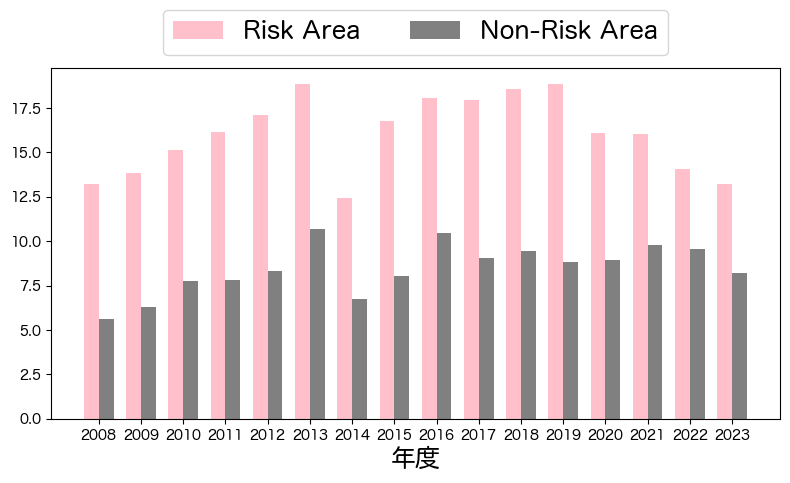

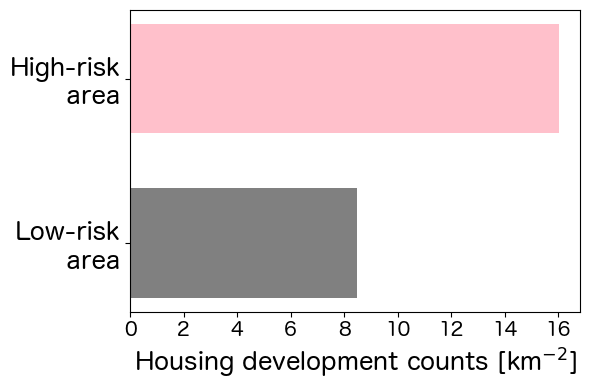

In [32]:
thres = 0.05
risk_area = choice_zone.loc[(choice_zone["risk_area"] / choice_zone["area_km2"] > thres), "選択ゾーン"].to_list()
non_risk_area = choice_zone.loc[(choice_zone["risk_area"] / choice_zone["area_km2"] <= thres), "選択ゾーン"].to_list()

# risk_areaとnon_risk_areaのそれぞれでゾーン面積あたりの住宅開発面積を計算
risk_dev_res = dev_res[risk_area].sum(axis=1) / choice_zone.set_index("選択ゾーン").loc[risk_area, "area_km2"].sum()
non_risk_dev_res = dev_res[non_risk_area].sum(axis=1) / choice_zone.set_index("選択ゾーン").loc[non_risk_area, "area_km2"].sum()
# risk. non_riskごとに年次の棒グラフで表示
plt.figure(figsize=(8, 5))
bar_width = 0.35
plt.bar([i - bar_width/2 for i in range(start_year, end_year+1)], risk_dev_res, width=bar_width, label="Risk Area", color="pink")
plt.bar([i + bar_width/2 for i in range(start_year, end_year+1)], non_risk_dev_res, width=bar_width, label="Non-Risk Area", color="gray")
plt.xlabel(r"年度", fontsize=18)
plt.xticks([i for i in range(start_year, end_year+1)], rotation=0)
plt.legend(fontsize=18, loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=2)
plt.tight_layout()
plt.savefig(f"../data/processed/pop_zone/risk_nonrisk_dev_res.png")
plt.show()

# 年もまとめて二つの横棒のグラフ
plt.figure(figsize=(6, 4))
bar_height = 0.04
plt.barh(0.53, risk_dev_res.mean(), height=bar_height, label="Risk Area", color="pink")
plt.barh(0.47, non_risk_dev_res.mean(), height=bar_height, label="Non-Risk Area", color="gray")
plt.xlabel(r"Housing development counts [km$^{-2}$]", fontsize=18)
plt.yticks([0.53, 0.47], ["High-risk\n area", "Low-risk\n area"], fontsize=18)
plt.xticks(fontsize=14)
#plt.legend(fontsize=18, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)
plt.tight_layout()
plt.savefig(f"../data/processed/pop_zone/risk_nonrisk_dev_res_avg.png")
plt.show()


# 居住地選択モデルの立地ポテンシャルの可視化

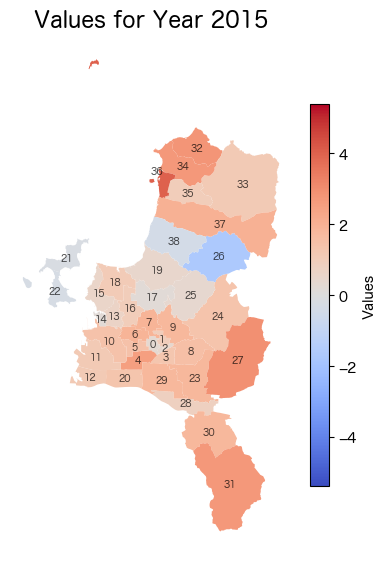

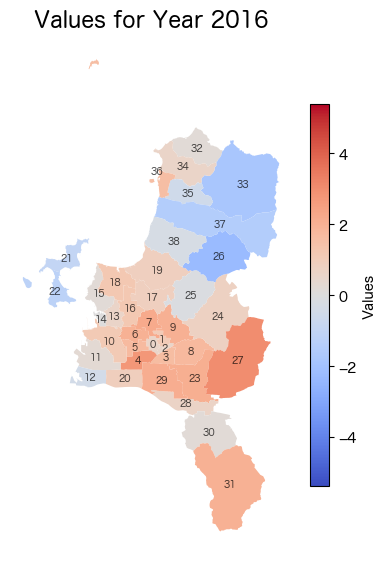

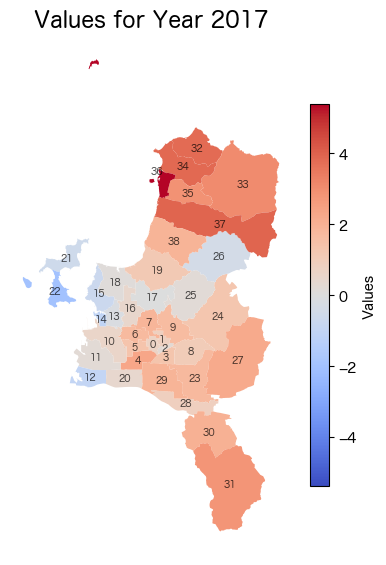

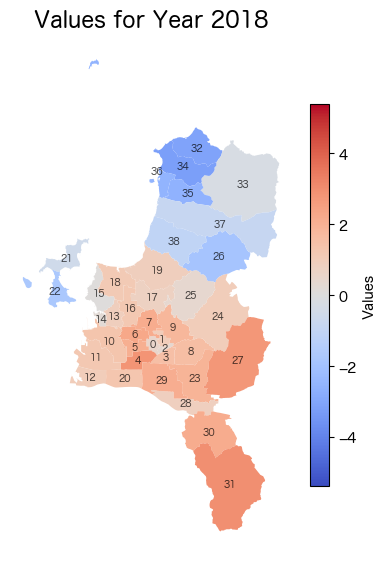

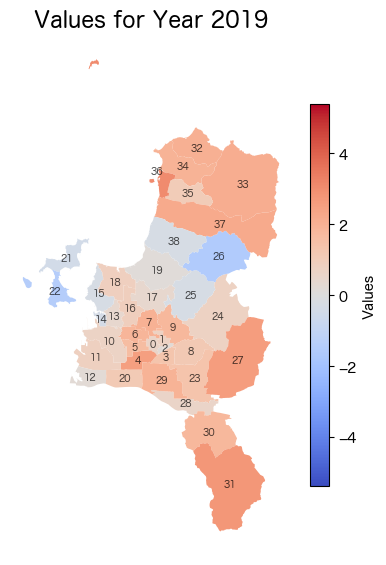

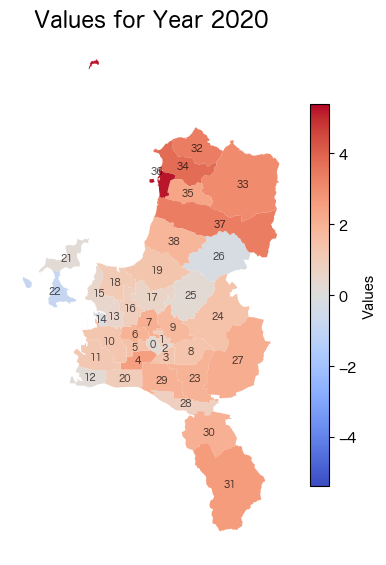

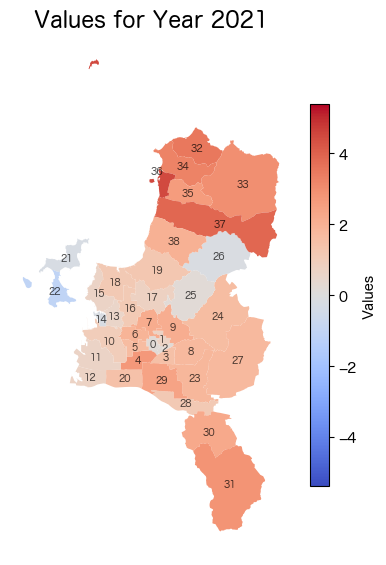

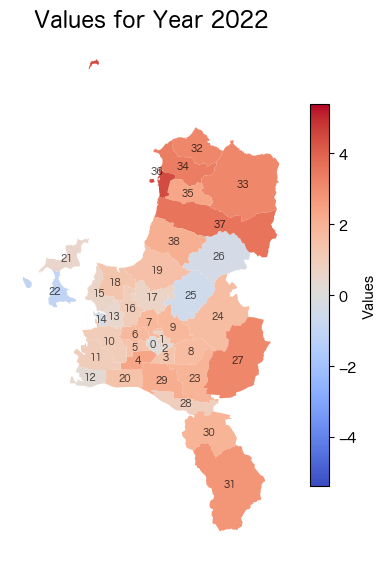

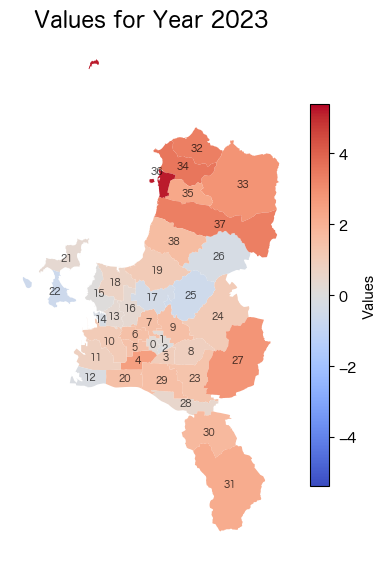

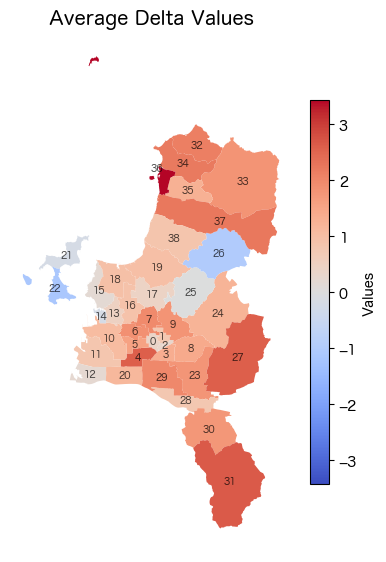

In [4]:
import json

# 読み込み
with open('../output/estimates/mxl_step1_results.json', 'r', encoding='utf-8') as f:
    mxl_step1_results = json.load(f)
pop_zone = gpd.read_file("../data/raw/zoning/pop_zone.geojson", encoding="utf-8")
start_year = 2015

for i in range(len(mxl_step1_results["delta"])):
    year = start_year + i
    pop_zone[f"delta_{year}"] = mxl_step1_results["delta"][i]

# delta値の全期間の最小/最大を取得し、全て同じスケールで描画（真ん中はゼロにする）
delta_cols = [f"delta_{start_year + i}" for i in range(len(mxl_step1_results["delta"]))]
min_val = min([pop_zone[col].min() for col in delta_cols])
max_val = max([pop_zone[col].max() for col in delta_cols])
# 真ん中(カラーマップ中央)を0にするためのvlim設定
abs_max = max(abs(min_val), abs(max_val))
vmin = -abs_max
vmax = abs_max

# 図示（年ごと）
for i in range(len(mxl_step1_results["delta"])):
    year = start_year + i
    plt.figure(figsize=(4, 6))
    ax = plt.gca()
    pop_zone.plot(
        column=f"delta_{year}", 
        ax=ax, 
        legend=True, 
        cmap='coolwarm', 
        vmin=vmin, 
        vmax=vmax, 
        legend_kwds={'label': "Values", 'shrink': 0.7}
    )
    # ゾーンのラベルを中心に描画
    for idx, row in pop_zone.iterrows():
        if hasattr(row.geometry, 'centroid'):
            x = row.geometry.centroid.x
            y = row.geometry.centroid.y
        else:
            # ポリゴンのみ
            x, y = row.geometry.centroid.xy
            x = x[0]
            y = y[0]
        # ゾーン名（もしくは"選択ゾーン" など）を表示
        label = str(row["選択ゾーン"])
        ax.text(x, y, label, fontsize=7, ha='center', va='center', color='black', alpha=0.7)
    plt.title(f"Values for Year {year}", fontsize=16)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(f"../output/estimates/plots/delta/delta_map_{year}.png", dpi=300)
    plt.show()

# 平均値も同一スケールで図示
pop_zone["delta_average"] = pop_zone[delta_cols].mean(axis=1)
abs_max = max(abs(pop_zone["delta_average"].min()), abs(pop_zone["delta_average"].max()))
vmin = -abs_max
vmax = abs_max
plt.figure(figsize=(4, 6))
ax = plt.gca()
pop_zone.plot(
    column="delta_average", 
    ax=ax, 
    legend=True, 
    cmap='coolwarm', 
    vmin=vmin, 
    vmax=vmax, 
    legend_kwds={'label': "Values", 'shrink': 0.7}
)
for idx, row in pop_zone.iterrows():
    if hasattr(row.geometry, 'centroid'):
        x = row.geometry.centroid.x
        y = row.geometry.centroid.y
    else:
        x, y = row.geometry.centroid.xy
        x = x[0]
        y = y[0]
    label = str(row["選択ゾーン"])
    ax.text(x, y, label, fontsize=7, ha='center', va='center', color='black', alpha=0.7)
plt.title("Average Delta Values", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig(f"../output/estimates/plots/delta/delta_map_average.png", dpi=300)
plt.show()

# 価値関数の可視化

In [1]:
import pandas as pd
import yaml
import numpy as np
import geopandas as gpd
import os
import sys
from matplotlib import pyplot as plt
import seaborn as sns
from shapely.geometry import Point
from tqdm import tqdm
# matplotlibの日本語フォントの設定
plt.rcParams['font.family'] = 'Hiragino Maru Gothic Pro'


# 親ディレクトリ（notebookの上の階層）をパスに追加
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

try:
    from model.forward_simulation import ForwardSimulation
    from model.forward_simulation import ForwardSimulation
    from model.policy_estimation import HeteroMLEPolicyFunction
    from utils.config_manager import ConfigManager
    from utils.data_loader import load_simulation_data
except ModuleNotFoundError as e:
    print("ModuleNotFoundError:", e)
    print("Check that the 'model' directory is present and contains 'forward_simulation.py'")

/Users/masudasatoki/Library/Caches/pypoetry/virtualenvs/land-use-dynamic-game-z56Oqm0P-py3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-01-07 04:54:51,719	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
config = ConfigManager("config.yaml")

sim_start_year = 2009
ref_year = 1
n_forward = 100
end_year = config.end_year
seed = config.seed
horizon = config.horizon
discount_factor = config.discount_factor
data_bundle = load_simulation_data(config)
Rzone_list = data_bundle.Rzone_list
transition_model = data_bundle.transition_model
df = data_bundle.df_pt
data = data_bundle.data
Dzone_list = data_bundle.Dzone_list
Rzone_list = data_bundle.Rzone_list
Darea_list = data_bundle.Darea_list
features = data_bundle.features
zone_conversion = transition_model.zone_conversion
theta = {
    "gov": np.array(config.theta_gov),
    "dev": np.array(config.theta_dev)
}

gov_model = HeteroMLEPolicyFunction()
gov_model.load_model("../output/estimates/gov_model_mle.joblib")
dev_model = HeteroMLEPolicyFunction()
dev_model.load_model("../output/estimates/dev_model_mle.joblib")
# transition_model
if os.path.exists("../output/estimates/mxl_step1_results.json") and os.path.exists("../output/estimates/mxl_step2_results.json"):
    print("遷移モデルの推定結果が既に存在します。再推定をスキップします。")
    transition_model.load_estimates("../output/estimates/mxl_step1_results.json", "../output/estimates/mxl_step2_results.json", model="MXL_2step")

N0 = data.loc[(data['year'] == sim_start_year) & data['zone'].isin(Rzone_list), 'population_t_raw'].to_list()
I0 = data.loc[(data['year'] == sim_start_year), 'los_t_raw'].to_list()
P0 = data.loc[(data['year'] == sim_start_year), 'land_price_t_raw'].to_list()
development_lists = [data.loc[(data['year'] == sim_start_year-i), 'develop_res_t_raw'].to_list() for i in range(ref_year)]

V_zone = {}
forward_path_base = {}
mae_total = {"population": 0, "investment": 0, "development": 0, "price": 0}
mape_total = {"population": 0, "investment": 0, "development": 0, "price": 0}
for target_zone in tqdm(Dzone_list, desc="Forward Simulation for each zone"):
    forward_simulation = ForwardSimulation(
        N0=N0, I0=I0, P0=P0, development_lists=development_lists,
        zone=target_zone, start_year=sim_start_year, data_final_year=end_year, T=end_year - sim_start_year +1,
        discount_factor=discount_factor,
        gov_model=gov_model, dev_model=dev_model,
        base_gov_model=gov_model, base_dev_model=dev_model,
        transition_model=transition_model, features=features, df=df,
        zone_convert_dict=zone_conversion, area_list=Darea_list,
        master_seed=seed,
        transition_type="deterministic"
        )
    
    forward_paths = forward_simulation.generate_samples(n_forward)
    forward_path_base[target_zone] = forward_paths
    observation = {
        "population_path": data.loc[(data['year'] >= sim_start_year) & (data['year'] <= end_year) & (data['zone'] == target_zone), 'population_t_raw'].values,
        "investment_path": data.loc[(data['year'] >= sim_start_year) & (data['year'] <= end_year) & (data['zone'] == target_zone), 'los_t_raw'].values,
        "price_path": data.loc[(data['year'] >= sim_start_year) & (data['year'] <= end_year) & (data['zone'] == target_zone), 'land_price_t_raw'].values,
        "development_path": data.loc[(data['year'] >= sim_start_year) & (data['year'] <= end_year) & (data['zone'] == target_zone), 'develop_res_t_raw'].values
    }
    
    forward_simulation.in_sample_validation(output_dir="../output/simulation/validation/", observed_data=observation)
    mae_zone, mape_zone = forward_simulation.visualize_paths(output_dir="../output/simulation/forward_simulation/base_case/", observed_data=observation)
    
    for key in mae_total:
        mae_total[key] += mae_zone[key]
        mape_total[key] += mape_zone[key]
    
    W_gov_list = forward_paths["W_gov"]
    W_dev_list = forward_paths["W_dev"]
    
    V_zone[target_zone] = {
        "V_gov": np.dot(np.mean(W_gov_list, axis=0), theta["gov"].reshape(-1,1)),
        "V_dev": np.dot(np.mean(W_dev_list, axis=0), theta["dev"].reshape(-1,1))}

mae_avg = {k: v / len(Dzone_list) for k, v in mae_total.items()}
mape_avg = {k: v / len(Dzone_list) for k, v in mape_total.items()}
print(f"Overall MAE: {mae_avg}, Overall MAPE: {mape_avg}")
    

ゾーン数: 39
データ数: 1314
遷移モデルの推定結果が既に存在します。再推定をスキップします。


2026-01-07 04:55:06,156	INFO worker.py:1852 -- Started a local Ray instance.


Model parameters loaded successfully.


Forward Simulation for each zone: 100%|██████████| 19/19 [04:04<00:00, 12.85s/it]

Overall MAE: {'population': np.float64(1924.7592633748936), 'investment': np.float64(12.50118084354886), 'development': np.float64(3529.929297278204), 'price': np.float64(14360.382467407233)}, Overall MAPE: {'population': np.float64(8.036528044562397), 'investment': np.float64(4.459635930177893), 'development': np.float64(23.389703198507608), 'price': np.float64(13.680313684191905)}


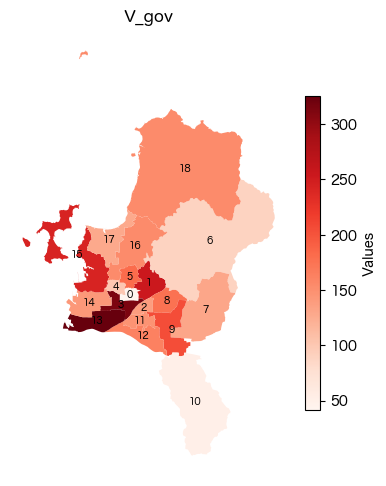

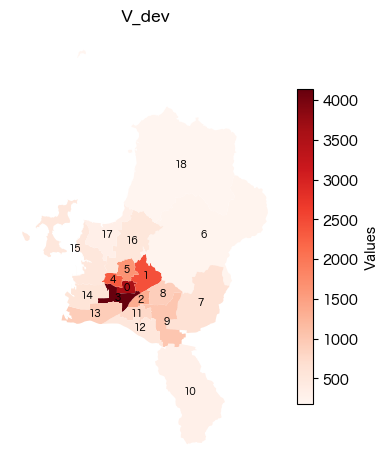

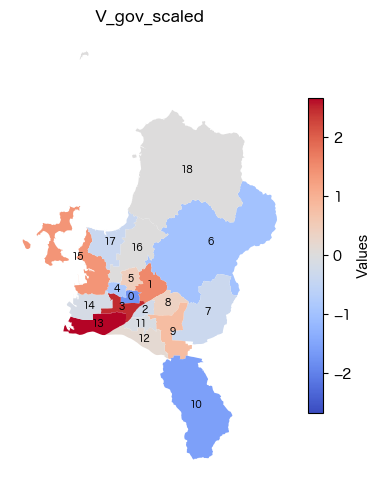

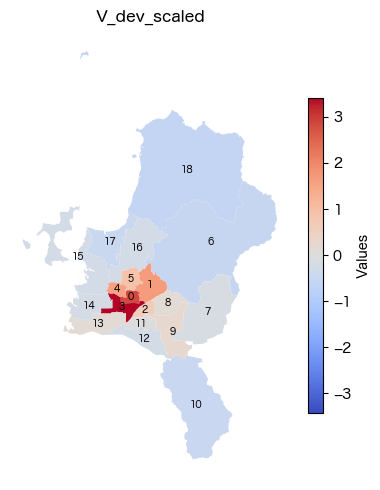

In [3]:
# V_zoneを図示
Dzone = gpd.read_file("../data/raw/zoning/19_zone.geojson", encoding="utf-8")
Dzone["V_gov"] = Dzone["選択ゾーン"].map(lambda x: V_zone[x]["V_gov"][0] if x in V_zone else None)
Dzone["V_dev"] = Dzone["選択ゾーン"].map(lambda x: V_zone[x]["V_dev"][0] if x in V_zone else None)
# 標準化
#Dzone["V_gov_scaled"] = (Dzone["V_gov"] - Dzone["V_gov"].mean()) / Dzone["V_gov"].std()
#Dzone["V_dev_scaled"] = (Dzone["V_dev"] - Dzone["V_dev"].mean()) / Dzone["V_dev"].std()
# min-maxスケーリング
#Dzone["V_gov_scaled"] = (Dzone["V_gov"] - Dzone["V_gov"].min()) / (Dzone["V_gov"].max() - Dzone["V_gov"].min())
#Dzone["V_dev_scaled"] = (Dzone["V_dev"] - Dzone["V_dev"].min()) / (Dzone["V_dev"].max() - Dzone["V_dev"].min())
# ロバストスケーリング
Dzone["V_gov_scaled"] = (Dzone["V_gov"] - Dzone["V_gov"].median()) / (Dzone["V_gov"].quantile(0.75) - Dzone["V_gov"].quantile(0.25))
Dzone["V_dev_scaled"] = (Dzone["V_dev"] - Dzone["V_dev"].median()) / (Dzone["V_dev"].quantile(0.75) - Dzone["V_dev"].quantile(0.25))

# V_gov, V_devの図示
for col in ["V_gov", "V_dev"]:
    plt.figure(figsize=(4, 5))
    ax = plt.gca()
    Dzone.plot(
        column=col, 
        ax=ax, 
        legend=True, 
        cmap='Reds',
        legend_kwds={'label': "Values", 'shrink': 0.7}
    )
    # ゾーン番号を書く
    for idx, row in Dzone.iterrows():
        if hasattr(row.geometry, 'centroid'):
            x = row.geometry.centroid.x
            y = row.geometry.centroid.y
        else:
            x, y = row.geometry.centroid.xy
            x = x[0]
            y = y[0]
        label = str(row["選択ゾーン"])
        ax.text(x, y, label, fontsize=7, ha='center', va='center', color='black', alpha=1.0)
        
    plt.title(f"{col}", fontsize=12)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(f"../output/value_function/{col}_map.png", dpi=300)
    plt.show()

# V_gov_scaled, V_dev_scaledの図示
for col in ["V_gov_scaled", "V_dev_scaled"]:
    # 真ん中(カラーマップ中央)を0にするためのvlim設定
    abs_max = max(abs(Dzone[col].min()), abs(Dzone[col].max()))
    vmin = -abs_max
    vmax = abs_max
    plt.figure(figsize=(4, 5))
    ax = plt.gca()
    Dzone.plot(
        column=col, 
        ax=ax, 
        legend=True, 
        cmap='coolwarm',
        legend_kwds={'label': "Values", 'shrink': 0.7},
        vmin=vmin,
        vmax=vmax
    )
    # ゾーン番号を書く
    for idx, row in Dzone.iterrows():
        if hasattr(row.geometry, 'centroid'):
            x = row.geometry.centroid.x
            y = row.geometry.centroid.y
        else:
            x, y = row.geometry.centroid.xy
            x = x[0]
            y = y[0]
        label = str(row["選択ゾーン"])
        ax.text(x, y, label, fontsize=7, ha='center', va='center', color='black', alpha=1.0)
    plt.title(f"{col}", fontsize=12)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(f"../output/value_function/{col}_map.png", dpi=300)
    plt.show()


## 立地規制

In [20]:
# 立地規制
from simulation.policy_override import PolicyLocationControl
regulate_zone = 12

upper_cap_dev = data.loc[data["zone"]==regulate_zone, "develop_res_t_raw"].mean() * 0.5
dev_wrap = PolicyLocationControl(dev_model)
dev_wrap.set_location_cap(regulate_zone , upper_cap_dev)
    
V_zone = {}
forward_path_cf1 = {}
for target_zone in tqdm(Dzone_list, desc="Forward Simulation for each zone"):
    forward_simulation = ForwardSimulation(
        N0=N0, I0=I0, P0=P0, development_lists=development_lists,
        zone=target_zone, start_year=sim_start_year, data_final_year=end_year, T=end_year - sim_start_year +1,
        discount_factor=discount_factor,
        gov_model=gov_model, dev_model=dev_wrap,
        base_gov_model=gov_model, base_dev_model=dev_wrap,
        transition_model=transition_model, features=features, df=df,
        zone_convert_dict=zone_conversion, area_list=Darea_list,
        master_seed=seed,
        transition_type="deterministic"
    )
    
    forward_paths = forward_simulation.generate_samples(n_forward)
    forward_path_cf1[target_zone] = forward_paths
        
    base_data = {
        "population_path": np.concatenate((
            np.array([N0[target_zone]]), 
            np.mean(forward_path_base[target_zone]["population_path"], axis=0)[:, target_zone]
        ), axis=0),
        "investment_path": np.concatenate((
            np.array([I0[target_zone]]), 
            np.mean(forward_path_base[target_zone]["investment_path"], axis=0)[:, target_zone]
        ), axis=0),
        "price_path": np.concatenate((
            np.array([P0[target_zone]]), 
            np.mean(forward_path_base[target_zone]["price_path"], axis=0)[:, target_zone]
        ), axis=0),
        "development_path": np.concatenate((
            np.array([development_lists[-1][target_zone]]), 
            np.mean(forward_path_base[target_zone]["development_path"], axis=0)[:, target_zone]
        ), axis=0)
    }
    _, _ = forward_simulation.visualize_paths(output_dir="../output/simulation/forward_simulation/cf1/", observed_data=base_data, name_observed="Base Case")
    
    W_gov_list = forward_paths["W_gov"]
    W_dev_list = forward_paths["W_dev"]
        
    V_zone[target_zone] = {
        "V_gov": np.dot(np.mean(np.array(W_gov_list), axis=0), theta["gov"].reshape(-1,1)),
        "V_dev": np.dot(np.mean(np.array(W_dev_list), axis=0), theta["dev"].reshape(-1,1))}
    

Forward Simulation for each zone: 100%|██████████| 19/19 [03:48<00:00, 12.02s/it]


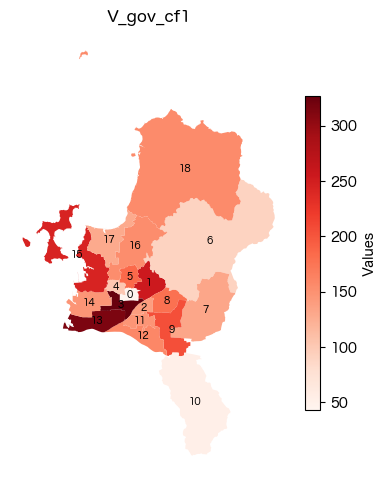

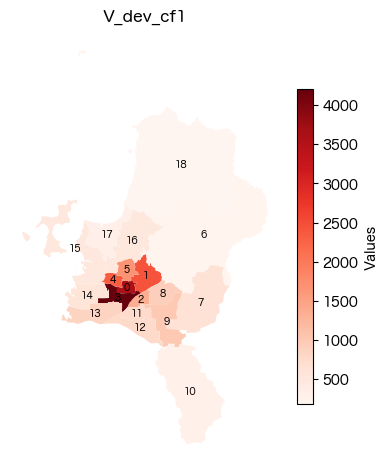

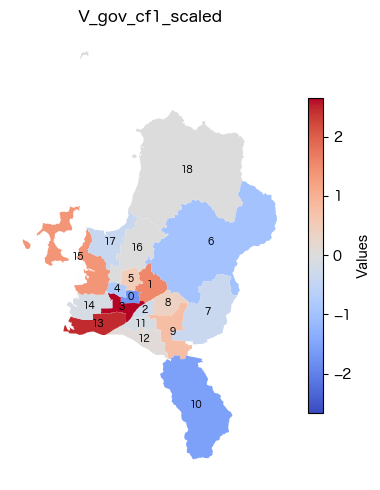

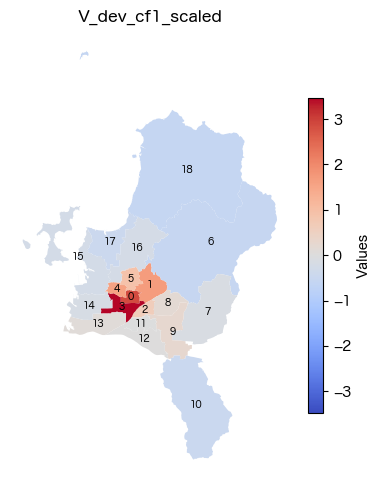

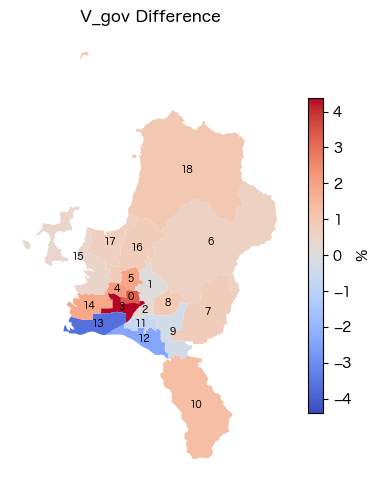

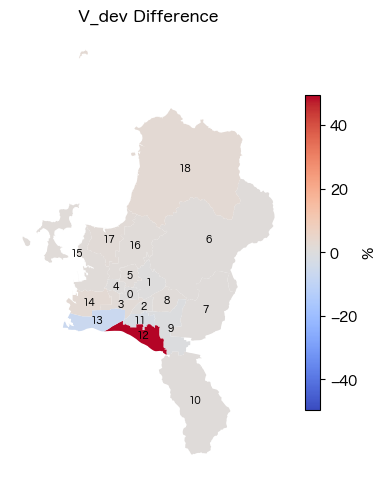

In [21]:
# V_zoneを図示
Dzone["V_gov_cf1"] = Dzone["選択ゾーン"].map(lambda x: V_zone[x]["V_gov"][0] if x in V_zone else None)
Dzone["V_dev_cf1"] = Dzone["選択ゾーン"].map(lambda x: V_zone[x]["V_dev"][0] if x in V_zone else None)
# 標準化
#Dzone["V_gov_cf1_scaled"] = (Dzone["V_gov_cf1"] - Dzone["V_gov_cf1"].mean()) / Dzone["V_gov_cf1"].std()
#Dzone["V_dev_cf1_scaled"] = (Dzone["V_dev_cf1"] - Dzone["V_dev_cf1"].mean()) / Dzone["V_dev_cf1"].std()
# min-maxスケーリング
#Dzone["V_gov_cf1_scaled"] = (Dzone["V_gov_cf1"] - Dzone["V_gov_cf1"].min()) / (Dzone["V_gov_cf1"].max() - Dzone["V_gov_cf1"].min())
#Dzone["V_dev_cf1_scaled"] = (Dzone["V_dev_cf1"] - Dzone["V_dev_cf1"].min()) / (Dzone["V_dev_cf1"].max() - Dzone["V_dev_cf1"].min())
# ロバストスケーリング
Dzone["V_gov_cf1_scaled"] = (Dzone["V_gov_cf1"] - Dzone["V_gov_cf1"].median()) / (Dzone["V_gov_cf1"].quantile(0.75) - Dzone["V_gov_cf1"].quantile(0.25))
Dzone["V_dev_cf1_scaled"] = (Dzone["V_dev_cf1"] - Dzone["V_dev_cf1"].median()) / (Dzone["V_dev_cf1"].quantile(0.75) - Dzone["V_dev_cf1"].quantile(0.25))

# V_gov, V_devの図示
for col in ["V_gov_cf1", "V_dev_cf1"]:
    plt.figure(figsize=(4, 5))
    ax = plt.gca()
    Dzone.plot(
        column=col, 
        ax=ax, 
        legend=True, 
        cmap='Reds',
        legend_kwds={'label': "Values", 'shrink': 0.7}
    )
    # ゾーン番号を書く
    for idx, row in Dzone.iterrows():
        if hasattr(row.geometry, 'centroid'):
            x = row.geometry.centroid.x
            y = row.geometry.centroid.y
        else:
            x, y = row.geometry.centroid.xy
            x = x[0]
            y = y[0]
        label = str(row["選択ゾーン"])
        ax.text(x, y, label, fontsize=7, ha='center', va='center', color='black', alpha=1.0)
        
    plt.title(f"{col}", fontsize=12)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(f"../output/value_function/{col}_map.png", dpi=300)
    plt.show()

# V_gov_scaled, V_dev_scaledの図示
for col in ["V_gov_cf1_scaled", "V_dev_cf1_scaled"]:
    # 真ん中(カラーマップ中央)を0にするためのvlim設定
    abs_max = max(abs(Dzone[col].min()), abs(Dzone[col].max()))
    vmin = -abs_max
    vmax = abs_max
    plt.figure(figsize=(4, 5))
    ax = plt.gca()
    Dzone.plot(
        column=col, 
        ax=ax, 
        legend=True, 
        cmap='coolwarm',
        legend_kwds={'label': "Values", 'shrink': 0.7},
        vmin=vmin,
        vmax=vmax
    )
    # ゾーン番号を書く
    for idx, row in Dzone.iterrows():
        if hasattr(row.geometry, 'centroid'):
            x = row.geometry.centroid.x
            y = row.geometry.centroid.y
        else:
            x, y = row.geometry.centroid.xy
            x = x[0]
            y = y[0]
        label = str(row["選択ゾーン"])
        ax.text(x, y, label, fontsize=7, ha='center', va='center', color='black', alpha=1.0)
        
    plt.title(f"{col}", fontsize=12)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(f"../output/value_function/{col}_map.png", dpi=300)
    plt.show()

# V_gov - V_gov_cf1, V_dev - V_dev_cf1の差分を図示
for col_base, col_cf in [("V_gov", "V_gov_cf1"), ("V_dev", "V_dev_cf1")]:
    Dzone[f"{col_cf}_diff"] = (Dzone[col_cf] - Dzone[col_base]) / np.abs(Dzone[col_base]) * 100.0  # パーセンテージ差分 
    # 真ん中(カラーマップ中央)を0にするためのvlim設定
    abs_max = max(abs(Dzone[f"{col_cf}_diff"].min()), abs(Dzone[f"{col_cf}_diff"].max()))
    vmin = -abs_max
    vmax = abs_max
    plt.figure(figsize=(4, 5))
    ax = plt.gca()
    Dzone.plot(
        column=f"{col_cf}_diff", 
        ax=ax, 
        legend=True, 
        cmap='coolwarm',
        legend_kwds={'label': "%", 'shrink': 0.7},
        vmin=vmin,
        vmax=vmax
    )
    # ゾーン番号を書く
    for idx, row in Dzone.iterrows():
        if hasattr(row.geometry, 'centroid'):
            x = row.geometry.centroid.x
            y = row.geometry.centroid.y
        else:
            x, y = row.geometry.centroid.xy
            x = x[0]
            y = y[0]
        label = str(row["選択ゾーン"])
        ax.text(x, y, label, fontsize=7, ha='center', va='center', color='black', alpha=1.0)
        
    plt.title(f"{col_base} Difference", fontsize=12)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(f"../output/value_function/{col_cf}_diff_map.png", dpi=300)
    plt.show()



In [18]:
print(Dzone[["V_gov_cf1_diff", "V_dev_cf1_diff"]].sum(axis=0))
Dzone[["V_gov_cf1_diff", "V_dev_cf1_diff"]]

V_gov_cf1_diff    12.148610
V_dev_cf1_diff    35.501493
dtype: float64


,V_gov_cf1_diff,V_dev_cf1_diff
0,2.639110,0.238357
1,0.063486,0.289092
2,0.198547,0.348417
3,2.795267,0.993994
4,1.618101,0.513768
5,1.474204,1.181787
6,0.357386,0.602606
7,0.366436,0.557996
8,0.718062,0.961401
9,0.464664,0.629398


In [22]:
investment_D = np.mean(forward_path_base[regulate_zone]["investment_path"], axis=0)[-1, :]
price_D = np.mean(forward_path_base[regulate_zone]["price_path"], axis=0)[-1, :]
base_welfare_car, base_welfare_noncar = transition_model.calculate_welfare(price_D, investment_D, end_year)

investment_D = np.mean(forward_path_cf1[regulate_zone]["investment_path"], axis=0)[-1, :]
price_D = np.mean(forward_path_cf1[regulate_zone]["price_path"], axis=0)[-1, :]
cf1_welfare_car, cf1_welfare_noncar = transition_model.calculate_welfare(price_D, investment_D, end_year)

print(f"Welfare change [JPY] in zone {regulate_zone}: Car: {cf1_welfare_car - base_welfare_car}, Non-Car: {cf1_welfare_noncar - base_welfare_noncar}")
print(f"Welfare change [%] in zone {regulate_zone}: Car: {(cf1_welfare_car - base_welfare_car) / base_welfare_car * 100.0}, Non-Car: {(cf1_welfare_noncar - base_welfare_noncar) / base_welfare_noncar * 100.0}")

Welfare change [JPY] in zone 12: Car: -38.0206025573425, Non-Car: -896.0434408262372
Welfare change [%] in zone 12: Car: -0.0046533321316347565, Non-Car: -0.07160089908993485


## 内陸の公共交通投資

In [31]:
pub_zone = 14

from simulation.policy_override import PolicyOverride
const_los = data.loc[data["zone"]==pub_zone, "los_t_raw"].values[0] + 100.0
gov_wrap = PolicyOverride(gov_model)
for t in range(end_year - sim_start_year +1):
    gov_wrap.set_override(t, pub_zone, "gov", const_los)


V_zone = {}
forward_path_cf2 = {}
for target_zone in tqdm(Dzone_list, desc="Forward Simulation for each zone"):
    forward_simulation = ForwardSimulation(
        N0=N0, I0=I0, P0=P0, development_lists=development_lists,
        zone=target_zone, start_year=sim_start_year, data_final_year=end_year, T=end_year - sim_start_year +1,
        discount_factor=discount_factor,
        gov_model=gov_wrap, dev_model=dev_model,
        base_gov_model=gov_wrap, base_dev_model=dev_model,
        transition_model=transition_model, features=features, df=df,
        zone_convert_dict=zone_conversion, area_list=Darea_list,
        master_seed=seed,
        transition_type="deterministic"
    )
    forward_paths = forward_simulation.generate_samples(n_forward)
    forward_path_cf2[target_zone] = forward_paths
    
    base_data = {
        "population_path": np.concatenate((
            np.array([N0[target_zone]]), 
            np.mean(forward_path_base[target_zone]["population_path"], axis=0)[:, target_zone]
        ), axis=0),
        "investment_path": np.concatenate((
            np.array([I0[target_zone]]), 
            np.mean(forward_path_base[target_zone]["investment_path"], axis=0)[:, target_zone]
        ), axis=0),
        "price_path": np.concatenate((
            np.array([P0[target_zone]]), 
            np.mean(forward_path_base[target_zone]["price_path"], axis=0)[:, target_zone]
        ), axis=0),
        "development_path": np.concatenate((
            np.array([development_lists[-1][target_zone]]), 
            np.mean(forward_path_base[target_zone]["development_path"], axis=0)[:, target_zone]
        ), axis=0)
    }
    
    _, _ = forward_simulation.visualize_paths(output_dir="../output/simulation/forward_simulation/cf2/", observed_data=base_data, name_observed="Base Case")
    
    W_gov_list = forward_paths["W_gov"]
    W_dev_list = forward_paths["W_dev"]
        
    V_zone[target_zone] = {
        "V_gov": np.dot(np.mean(np.array(W_gov_list), axis=0), theta["gov"].reshape(-1,1)),
        "V_dev": np.dot(np.mean(np.array(W_dev_list), axis=0), theta["dev"].reshape(-1,1))}

Forward Simulation for each zone: 100%|██████████| 19/19 [04:14<00:00, 13.42s/it]


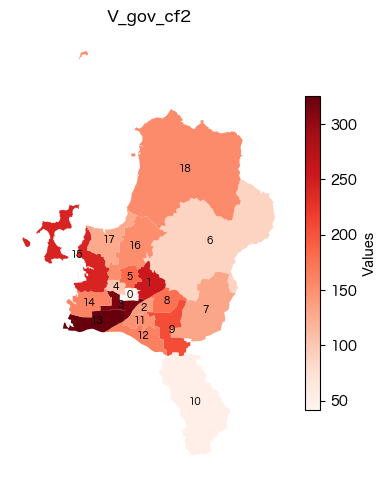

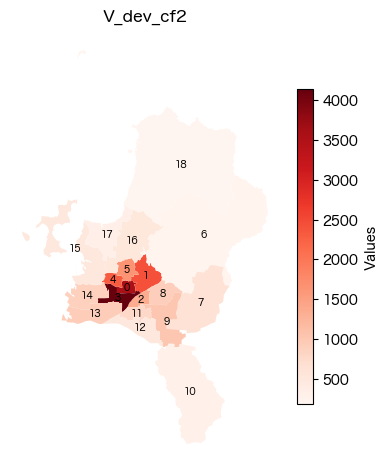

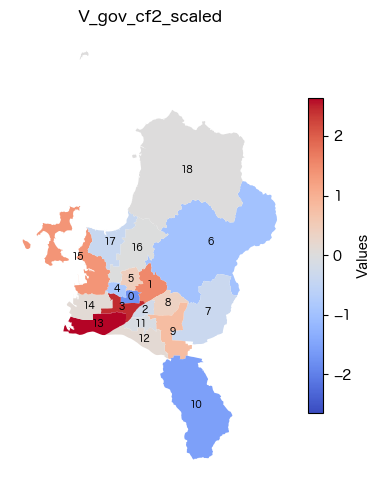

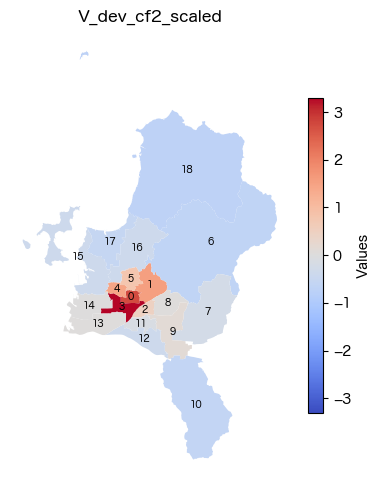

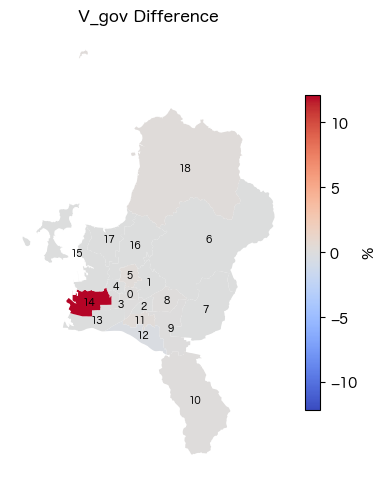

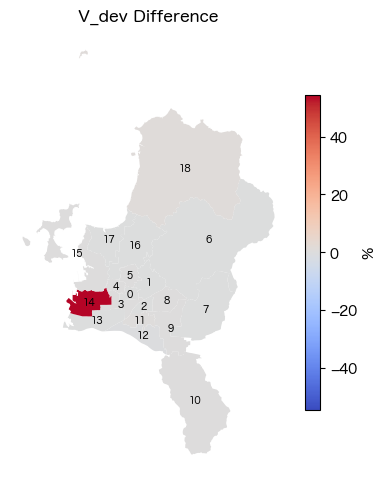

In [32]:
# V_zoneを図示
Dzone["V_gov_cf2"] = Dzone["選択ゾーン"].map(lambda x: V_zone[x]["V_gov"][0] if x in V_zone else None)
Dzone["V_dev_cf2"] = Dzone["選択ゾーン"].map(lambda x: V_zone[x]["V_dev"][0] if x in V_zone else None)
# 標準化
#Dzone["V_gov_cf1_scaled"] = (Dzone["V_gov_cf1"] - Dzone["V_gov_cf1"].mean()) / Dzone["V_gov_cf1"].std()
#Dzone["V_dev_cf1_scaled"] = (Dzone["V_dev_cf1"] - Dzone["V_dev_cf1"].mean()) / Dzone["V_dev_cf1"].std()
# min-maxスケーリング
#Dzone["V_gov_cf1_scaled"] = (Dzone["V_gov_cf1"] - Dzone["V_gov_cf1"].min()) / (Dzone["V_gov_cf1"].max() - Dzone["V_gov_cf1"].min())
#Dzone["V_dev_cf1_scaled"] = (Dzone["V_dev_cf1"] - Dzone["V_dev_cf1"].min()) / (Dzone["V_dev_cf1"].max() - Dzone["V_dev_cf1"].min())
# ロバストスケーリング
Dzone["V_gov_cf2_scaled"] = (Dzone["V_gov_cf2"] - Dzone["V_gov_cf2"].median()) / (Dzone["V_gov_cf2"].quantile(0.75) - Dzone["V_gov_cf2"].quantile(0.25))
Dzone["V_dev_cf2_scaled"] = (Dzone["V_dev_cf2"] - Dzone["V_dev_cf2"].median()) / (Dzone["V_dev_cf2"].quantile(0.75) - Dzone["V_dev_cf2"].quantile(0.25))

# V_gov, V_devの図示
for col in ["V_gov_cf2", "V_dev_cf2"]:
    plt.figure(figsize=(4, 5))
    ax = plt.gca()
    Dzone.plot(
        column=col, 
        ax=ax, 
        legend=True, 
        cmap='Reds',
        legend_kwds={'label': "Values", 'shrink': 0.7}
    )
    # ゾーン番号を書く
    for idx, row in Dzone.iterrows():
        if hasattr(row.geometry, 'centroid'):
            x = row.geometry.centroid.x
            y = row.geometry.centroid.y
        else:
            x, y = row.geometry.centroid.xy
            x = x[0]
            y = y[0]
        label = str(row["選択ゾーン"])
        ax.text(x, y, label, fontsize=7, ha='center', va='center', color='black', alpha=1.0)
        
    plt.title(f"{col}", fontsize=12)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(f"../output/value_function/{col}_map.png", dpi=300)
    plt.show()

# V_gov_scaled, V_dev_scaledの図示
for col in ["V_gov_cf2_scaled", "V_dev_cf2_scaled"]:
    # 真ん中(カラーマップ中央)を0にするためのvlim設定
    abs_max = max(abs(Dzone[col].min()), abs(Dzone[col].max()))
    vmin = -abs_max
    vmax = abs_max
    plt.figure(figsize=(4, 5))
    ax = plt.gca()
    Dzone.plot(
        column=col, 
        ax=ax, 
        legend=True, 
        cmap='coolwarm',
        legend_kwds={'label': "Values", 'shrink': 0.7},
        vmin=vmin,
        vmax=vmax
    )
    # ゾーン番号を書く
    for idx, row in Dzone.iterrows():
        if hasattr(row.geometry, 'centroid'):
            x = row.geometry.centroid.x
            y = row.geometry.centroid.y
        else:
            x, y = row.geometry.centroid.xy
            x = x[0]
            y = y[0]
        label = str(row["選択ゾーン"])
        ax.text(x, y, label, fontsize=7, ha='center', va='center', color='black', alpha=1.0)
        
    plt.title(f"{col}", fontsize=12)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(f"../output/value_function/{col}_map.png", dpi=300)
    plt.show()

# V_gov - V_gov_cf1, V_dev - V_dev_cf1の差分を図示
for col_base, col_cf in [("V_gov", "V_gov_cf2"), ("V_dev", "V_dev_cf2")]:
    Dzone[f"{col_cf}_diff"] = (Dzone[col_cf] - Dzone[col_base]) / np.abs(Dzone[col_base]) * 100.0  # パーセンテージ差分
    # 真ん中(カラーマップ中央)を0にするためのvlim設定
    abs_max = max(abs(Dzone[f"{col_cf}_diff"].min()), abs(Dzone[f"{col_cf}_diff"].max()))
    vmin = -abs_max
    vmax = abs_max
    plt.figure(figsize=(4, 5))
    ax = plt.gca()
    Dzone.plot(
        column=f"{col_cf}_diff", 
        ax=ax, 
        legend=True, 
        cmap='coolwarm',
        legend_kwds={'label': "%", 'shrink': 0.7},
        vmin=vmin,
        vmax=vmax
    )
    # ゾーン番号を書く
    for idx, row in Dzone.iterrows():
        if hasattr(row.geometry, 'centroid'):
            x = row.geometry.centroid.x
            y = row.geometry.centroid.y
        else:
            x, y = row.geometry.centroid.xy
            x = x[0]
            y = y[0]
        label = str(row["選択ゾーン"])
        ax.text(x, y, label, fontsize=7, ha='center', va='center', color='black', alpha=1.0)
        
    plt.title(f"{col_base} Difference", fontsize=12)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(f"../output/value_function/{col_cf}_diff_map.png", dpi=300)
    plt.show()



In [33]:
print(Dzone[["V_gov_cf2_diff", "V_dev_cf2_diff"]].sum(axis=0))
Dzone[["V_gov_cf2_diff", "V_dev_cf2_diff"]]

V_gov_cf2_diff    12.862880
V_dev_cf2_diff    55.395422
dtype: float64


,V_gov_cf2_diff,V_dev_cf2_diff
0,0.114113,-0.015511
1,-0.013325,-0.011026
2,-0.042234,-0.165678
3,0.036076,0.040554
4,-0.022405,0.008835
5,0.339089,0.224819
6,-0.083333,-0.026490
7,-0.068016,-0.046045
8,0.135566,0.143688
9,0.047177,0.021579


In [34]:
investment_D = np.mean(forward_path_base[pub_zone]["investment_path"], axis=0)[-1, :]
price_D = np.mean(forward_path_base[pub_zone]["price_path"], axis=0)[-1, :]
base_welfare_car, base_welfare_noncar = transition_model.calculate_welfare(price_D, investment_D, end_year)

investment_D = np.mean(forward_path_cf2[pub_zone]["investment_path"], axis=0)[-1, :]
price_D = np.mean(forward_path_cf2[pub_zone]["price_path"], axis=0)[-1, :]
cf2_welfare_car, cf2_welfare_noncar = transition_model.calculate_welfare(price_D, investment_D, end_year)

print(f"Welfare change [JPY] in zone {pub_zone}: Car: {cf2_welfare_car - base_welfare_car}, Non-Car: {cf2_welfare_noncar - base_welfare_noncar}")
print(f"Welfare change [%] in zone {pub_zone}: Car: {(cf2_welfare_car - base_welfare_car) / base_welfare_car * 100.0}, Non-Car: {(cf2_welfare_noncar - base_welfare_noncar) / base_welfare_noncar * 100.0}")

Welfare change [JPY] in zone 14: Car: 137.5854423744604, Non-Car: 365.52393971104175
Welfare change [%] in zone 14: Car: 0.016842400331582654, Non-Car: 0.02921168843445774


## ゾーン12の公共交通投資規制

In [ ]:
from simulation.policy_override import PolicyTransportControl
regulate_zone = 12

upper_cap_gov = data.loc[data["zone"]==regulate_zone, "los_t_raw"].mean() * 0.2
gov_wrap = PolicyTransportControl(gov_model)
gov_wrap.set_transport_cap(regulate_zone, upper_cap_gov)

V_zone = {}
forward_path_cf3 = {}
for target_zone in tqdm(Dzone_list, desc="Forward Simulation for each zone"):
    forward_simulation = ForwardSimulation(
        N0=N0, I0=I0, P0=P0, development_lists=development_lists,
        zone=target_zone, start_year=sim_start_year, data_final_year=end_year, T=end_year - sim_start_year +1,
        discount_factor=discount_factor,
        gov_model=gov_wrap, dev_model=dev_model,
        base_gov_model=gov_wrap, base_dev_model=dev_model,
        transition_model=transition_model, features=features, df=df,
        zone_convert_dict=zone_conversion, area_list=Darea_list,
        master_seed=seed,
        transition_type="deterministic"
    )
    forward_paths = forward_simulation.generate_samples(n_forward)
    forward_path_cf3[target_zone] = forward_paths
    
    base_data = {
        "population_path": np.concatenate((
            np.array([N0[target_zone]]), 
            np.mean(forward_path_base[target_zone]["population_path"], axis=0)[:, target_zone]
        ), axis=0),
        "investment_path": np.concatenate((
            np.array([I0[target_zone]]), 
            np.mean(forward_path_base[target_zone]["investment_path"], axis=0)[:, target_zone]
        ), axis=0),
        "price_path": np.concatenate((
            np.array([P0[target_zone]]), 
            np.mean(forward_path_base[target_zone]["price_path"], axis=0)[:, target_zone]
        ), axis=0),
        "development_path": np.concatenate((
            np.array([development_lists[-1][target_zone]]), 
            np.mean(forward_path_base[target_zone]["development_path"], axis=0)[:, target_zone]
        ), axis=0)
    }
    
    _, _ = forward_simulation.visualize_paths(output_dir="../output/simulation/forward_simulation/cf3/", observed_data=base_data, name_observed="Base Case")
    
    W_gov_list = forward_paths["W_gov"]
    W_dev_list = forward_paths["W_dev"]
        
    V_zone[target_zone] = {
        "V_gov": np.dot(np.mean(np.array(W_gov_list), axis=0), theta["gov"].reshape(-1,1)),
        "V_dev": np.dot(np.mean(np.array(W_dev_list), axis=0), theta["dev"].reshape(-1,1))}
    

Forward Simulation for each zone:  37%|███▋      | 7/19 [02:19<03:58, 19.88s/it]


: 

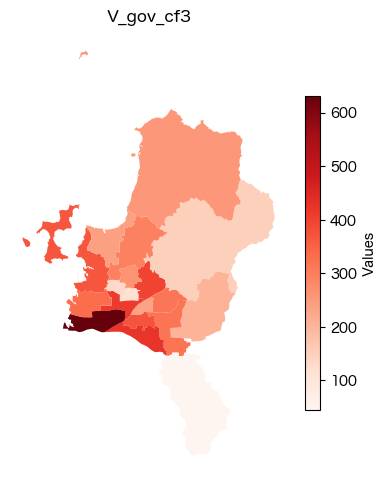

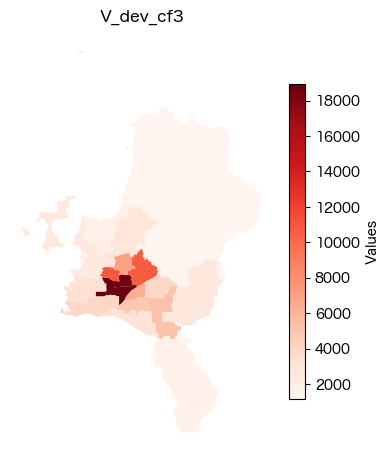

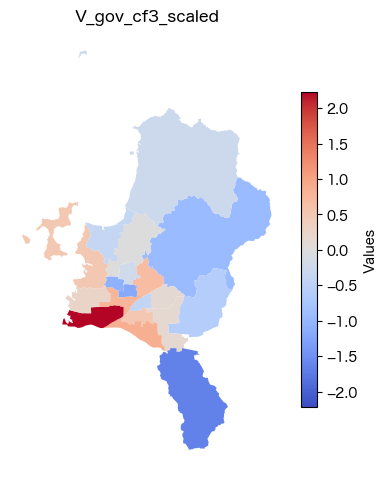

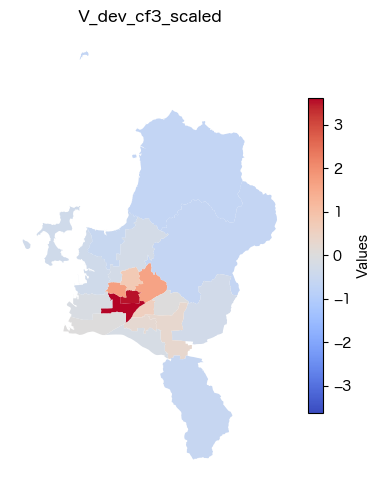

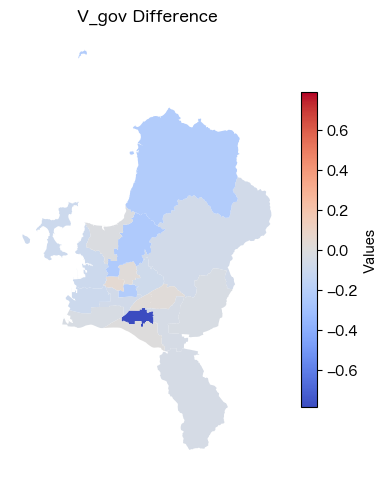

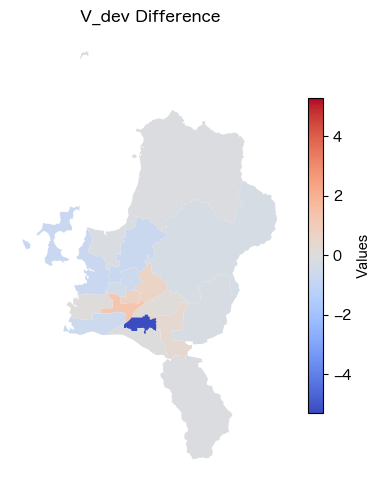

In [ ]:
# V_zoneを図示
Dzone["V_gov_cf3"] = Dzone["選択ゾーン"].map(lambda x: V_zone[x]["V_gov"][0] if x in V_zone else None)
Dzone["V_dev_cf3"] = Dzone["選択ゾーン"].map(lambda x: V_zone[x]["V_dev"][0] if x in V_zone else None)
# 標準化
#Dzone["V_gov_cf1_scaled"] = (Dzone["V_gov_cf1"] - Dzone["V_gov_cf1"].mean()) / Dzone["V_gov_cf1"].std()
#Dzone["V_dev_cf1_scaled"] = (Dzone["V_dev_cf1"] - Dzone["V_dev_cf1"].mean()) / Dzone["V_dev_cf1"].std()
# min-maxスケーリング
#Dzone["V_gov_cf1_scaled"] = (Dzone["V_gov_cf1"] - Dzone["V_gov_cf1"].min()) / (Dzone["V_gov_cf1"].max() - Dzone["V_gov_cf1"].min())
#Dzone["V_dev_cf1_scaled"] = (Dzone["V_dev_cf1"] - Dzone["V_dev_cf1"].min()) / (Dzone["V_dev_cf1"].max() - Dzone["V_dev_cf1"].min())
# ロバストスケーリング
Dzone["V_gov_cf3_scaled"] = (Dzone["V_gov_cf3"] - Dzone["V_gov_cf3"].median()) / (Dzone["V_gov_cf3"].quantile(0.75) - Dzone["V_gov_cf3"].quantile(0.25))
Dzone["V_dev_cf3_scaled"] = (Dzone["V_dev_cf3"] - Dzone["V_dev_cf3"].median()) / (Dzone["V_dev_cf3"].quantile(0.75) - Dzone["V_dev_cf3"].quantile(0.25))

# V_gov, V_devの図示
for col in ["V_gov_cf3", "V_dev_cf3"]:
    plt.figure(figsize=(4, 5))
    ax = plt.gca()
    Dzone.plot(
        column=col, 
        ax=ax, 
        legend=True, 
        cmap='Reds',
        legend_kwds={'label': "Values", 'shrink': 0.7}
    )
    # ゾーン番号を書く
    for idx, row in Dzone.iterrows():
        if hasattr(row.geometry, 'centroid'):
            x = row.geometry.centroid.x
            y = row.geometry.centroid.y
        else:
            x, y = row.geometry.centroid.xy
            x = x[0]
            y = y[0]
        label = str(row["選択ゾーン"])
        ax.text(x, y, label, fontsize=7, ha='center', va='center', color='black', alpha=1.0)
        
    plt.title(f"{col}", fontsize=12)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(f"../output/value_function/{col}_map.png", dpi=300)
    plt.show()

# V_gov_scaled, V_dev_scaledの図示
for col in ["V_gov_cf3_scaled", "V_dev_cf3_scaled"]:
    # 真ん中(カラーマップ中央)を0にするためのvlim設定
    abs_max = max(abs(Dzone[col].min()), abs(Dzone[col].max()))
    vmin = -abs_max
    vmax = abs_max
    plt.figure(figsize=(4, 5))
    ax = plt.gca()
    Dzone.plot(
        column=col, 
        ax=ax, 
        legend=True, 
        cmap='coolwarm',
        legend_kwds={'label': "Values", 'shrink': 0.7},
        vmin=vmin,
        vmax=vmax
    )
    # ゾーン番号を書く
    for idx, row in Dzone.iterrows():
        if hasattr(row.geometry, 'centroid'):
            x = row.geometry.centroid.x
            y = row.geometry.centroid.y
        else:
            x, y = row.geometry.centroid.xy
            x = x[0]
            y = y[0]
        label = str(row["選択ゾーン"])
        ax.text(x, y, label, fontsize=7, ha='center', va='center', color='black', alpha=1.0)
    
    plt.title(f"{col}", fontsize=12)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(f"../output/value_function/{col}_map.png", dpi=300)
    plt.show()

# V_gov - V_gov_cf1, V_dev - V_dev_cf1の差分を図示
for col_base, col_cf in [("V_gov", "V_gov_cf3"), ("V_dev", "V_dev_cf3")]:
    Dzone[f"{col_cf}_diff"] = (Dzone[col_cf] - Dzone[col_base]) / np.abs(Dzone[col_base]) * 100.0  # パーセンテージ差分
    # 真ん中(カラーマップ中央)を0にするためのvlim設定
    abs_max = max(abs(Dzone[f"{col_cf}_diff"].min()), abs(Dzone[f"{col_cf}_diff"].max()))
    vmin = -abs_max
    vmax = abs_max
    plt.figure(figsize=(4, 5))
    ax = plt.gca()
    Dzone.plot(
        column=f"{col_base}_diff", 
        ax=ax, 
        legend=True, 
        cmap='coolwarm',
        legend_kwds={'label': "%", 'shrink': 0.7},
        vmin=vmin,
        vmax=vmax
    )
    # ゾーン番号を書く
    for idx, row in Dzone.iterrows():
        if hasattr(row.geometry, 'centroid'):
            x = row.geometry.centroid.x
            y = row.geometry.centroid.y
        else:
            x, y = row.geometry.centroid.xy
            x = x[0]
            y = y[0]
        label = str(row["選択ゾーン"])
        ax.text(x, y, label, fontsize=7, ha='center', va='center', color='black', alpha=1.0)
        
    plt.title(f"{col_base} Difference", fontsize=12)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(f"../output/value_function/{col_cf}_diff_map.png", dpi=300)
    plt.show()



In [ ]:
Dzone[["V_gov_cf3_diff", "V_dev_cf3_diff"]]

In [ ]:
investment_D = np.mean(forward_path_base[regulate_zone]["investment_path"], axis=0)[-1, :]
price_D = np.mean(forward_path_base[regulate_zone]["price_path"], axis=0)[-1, :]
base_welfare_car, base_welfare_noncar = transition_model.calculate_welfare(price_D, investment_D, end_year)

investment_D = np.mean(forward_path_cf3[regulate_zone]["investment_path"], axis=0)[-1, :]
price_D = np.mean(forward_path_cf3[regulate_zone]["price_path"], axis=0)[-1, :]
cf3_welfare_car, cf3_welfare_noncar = transition_model.calculate_welfare(price_D, investment_D, end_year)

print(f"Welfare change [JPY] in zone {regulate_zone}: Car: {cf3_welfare_car - base_welfare_car}, Non-Car: {cf3_welfare_noncar - base_welfare_noncar}")
print(f"Welfare change [%] in zone {regulate_zone}: Car: {(cf3_welfare_car - base_welfare_car) / base_welfare_car * 100.0}, Non-Car: {(cf3_welfare_noncar - base_welfare_noncar) / base_welfare_noncar * 100.0}")

# 拡大係数の付与 (世帯→人口)

In [ ]:
df = pd.read_csv("../data/raw/PT/2023PT_setai.csv", encoding="utf-8")
df_kakudai = pd.read_excel("/Users/masudasatoki/Desktop/松山/PT/2023PT/data/20240821UDCM提供用データ_個人情報なし/データ/R05松山PT_入力データ3個人票（個人情報なし）_拡大係数付.xlsx", sheet_name="3個人票_R05調査")

kakudai = df_kakudai.groupby(["5_整理番号_市町村", "8_個人番号"])["拡大係数"].mean().unstack().sum(axis=1, skipna=True)
df["拡大係数"] = df["5_整理番号_市町村・ロット・SEQ"].map(kakudai)
df.dropna(subset=["拡大係数"], inplace=True)
df.to_csv("../data/raw/PT/2023PT_setai_with_kakudai.csv", index=False, encoding="utf-8-sig")

# 転居データの確認

In [ ]:
df = pd.read_csv("/Users/masudasatoki/Desktop/cpij2025/code/data/processed/pop_zone/df_pool_2015_2023.csv", encoding="utf-8")
choice_zone = gpd.read_file("../data/raw/zoning/pop_zone.geojson", encoding="utf-8")
zone_list = choice_zone["選択ゾーン"].tolist()
df = df[df["転居有無"]==1]
df

In [ ]:
set(zone_list) - set(arr.columns.tolist())

In [ ]:
arr[21]

In [ ]:
arr = df.groupby(["居住地_後_ゾーン", "転居年"])["転居有無"].count().unstack().fillna(0).replace(0, 0.1).T
for i in set(zone_list) - set(arr.columns.tolist()):
    arr.loc[:,i] = 0.1
# 列を選択ゾーンの順番に並べ替え
arr = arr[zone_list]
arr

In [ ]:
arr = arr.values / np.sum(arr.values, axis=1, keepdims=True)
pd.DataFrame(arr)

# 推定データの確認

In [5]:
# X1.npyを読み込む
start_year = 2015
end_year = 2023
X1_hetero = np.load(f"/Users/masudasatoki/Desktop/cpij2025/code/data/processed/pop_zone/X1_hetero_{start_year}_{end_year}.npy")
X1_mean = np.load(f"/Users/masudasatoki/Desktop/cpij2025/code/data/processed/pop_zone/X1_mean_{start_year}_{end_year}.npy")
X2 = np.load(f"/Users/masudasatoki/Desktop/cpij2025/code/data/processed/pop_zone/X2_{start_year}_{end_year}.npy")
y = np.load(f"/Users/masudasatoki/Desktop/cpij2025/code/data/processed/pop_zone/y_{start_year}_{end_year}.npy")
obs_share = np.load(f"/Users/masudasatoki/Desktop/cpij2025/code/data/processed/pop_zone/obs_share_{start_year}_{end_year}.npy")
Z = np.load(f"/Users/masudasatoki/Desktop/cpij2025/code/data/processed/pop_zone/Z_{start_year}_{end_year}.npy", allow_pickle=True)
relocation_years = np.load(f"/Users/masudasatoki/Desktop/cpij2025/code/data/processed/pop_zone/relocation_years_{start_year}_{end_year}.npy")

In [8]:
pd.DataFrame(obs_share.T)

,0,1,2,3,4,5,6,7,8
0,0.010323,0.009697,0.014023,0.009031,0.011502,0.010054,0.008293,0.009220,0.014255
1,0.028816,0.024963,0.025465,0.023206,0.020787,0.023992,0.021773,0.023331,0.022257
2,0.015005,0.013252,0.013949,0.011172,0.011280,0.015030,0.010963,0.013229,0.015255
3,0.049486,0.050001,0.048796,0.047889,0.051646,0.046207,0.047653,0.049388,0.051295
4,0.079145,0.077724,0.076545,0.079535,0.074502,0.079872,0.082803,0.081137,0.079443
5,0.029589,0.030135,0.029660,0.035953,0.032510,0.028029,0.030014,0.031669,0.030649
6,0.050563,0.050449,0.053512,0.051924,0.050760,0.055372,0.046601,0.046956,0.047349
7,0.059107,0.060444,0.058575,0.056182,0.059084,0.062430,0.067808,0.060078,0.058325
8,0.052061,0.055446,0.054530,0.058790,0.049405,0.051158,0.052557,0.057058,0.055852
9,0.056181,0.058952,0.056838,0.052417,0.056498,0.053570,0.066961,0.058341,0.060993


In [ ]:
transition_model.zoning

,ゾーン名,area_km2,選択ゾーン,UnitPrice_Condo_2008,UnitPrice_Attached_2008,UnitPrice_Condo_2009,UnitPrice_Attached_2009,UnitPrice_Condo_2010,UnitPrice_Attached_2010,UnitPrice_Condo_2011,...,kosodate_density,hospital_density,park_density,park_area,commercial_area,risk_area,lowuse_around,lowuse_self,lowuse_area,geometry
0,番町,1.383598,0,191429.0,196788.0,308566.0,196788.0,329972.0,214286.0,218190.0,...,14,39,5,0.489817,0.502596,0.06,0.000251,0.000000,0.000000,"POLYGON ((132.76711 33.83362, 132.76702 33.833..."
1,東雲,1.214096,1,226667.0,164725.0,330557.0,164725.0,376984.0,148718.0,370546.0,...,17,28,5,0.439757,0.308774,0.07,0.005085,0.000452,0.088916,"POLYGON ((132.77447 33.83889, 132.77429 33.838..."
2,八坂,0.577349,2,196557.0,237500.0,292722.0,166667.0,213571.0,148820.0,185689.0,...,20,24,5,0.298196,0.408202,0.07,0.038877,0.001690,0.043470,"POLYGON ((132.77433 33.83404, 132.77404 33.833..."
3,素鵞,2.219862,3,226667.0,124539.0,160000.0,106310.0,200000.0,143187.0,135000.0,...,14,15,7,0.127381,0.384409,0.10,0.101298,0.070552,0.696483,"POLYGON ((132.7778 33.8243, 132.77727 33.8243,..."
4,雄郡,3.687724,4,172106.0,181825.0,181833.0,142263.0,190943.0,201534.0,194497.0,...,9,12,5,0.018185,0.444335,0.21,0.138350,0.168966,1.221292,"POLYGON ((132.73713 33.82537, 132.73721 33.825..."
5,新玉,2.235436,5,180700.0,263859.0,236270.0,121970.0,185611.0,237808.0,179358.0,...,11,14,5,0.388988,0.416504,0.13,0.097230,0.052500,0.539952,"POLYGON ((132.74528 33.83305, 132.74528 33.832..."
6,味酒,2.932612,6,211643.0,189879.0,194854.0,136646.0,169298.0,161250.0,200396.0,...,10,8,6,0.359821,0.514081,0.52,0.139487,0.170542,1.222631,"POLYGON ((132.75075 33.84139, 132.75074 33.841..."
7,清水,3.637260,7,158498.0,133441.0,172353.0,161905.0,166697.0,149185.0,180476.0,...,9,10,8,0.022208,0.293186,0.14,0.337709,0.329888,0.976842,"POLYGON ((132.76113 33.8492, 132.76113 33.8492..."
8,桑原,6.112289,8,207703.0,118062.0,207703.0,149235.0,173462.0,181917.0,173462.0,...,11,3,3,0.020439,0.061635,0.00,0.605646,1.051193,1.735656,"POLYGON ((132.79117 33.82369, 132.79095 33.823..."
9,道後,6.253991,9,252216.0,98448.0,230707.0,133690.0,166032.0,135936.0,140879.0,...,5,8,4,0.143536,0.166716,0.07,0.547779,1.180616,2.155280,"POLYGON ((132.78414 33.84137, 132.7841 33.8413..."


In [ ]:
XZ_mask = np.array([
    [1, 1, 1, 1, 1],  # 世帯主年齢
    [1, 1, 1, 0, 1],  # 自動車有無
    [1, 1, 1, 1, 1]   # 子供有無
], dtype=int)
        
# 分散共分散行列のマスク
sigma_mask = np.array([
    [1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 1]
], dtype=int)
sigma_mask_mean = np.array([[1]], dtype=int)
time_steps = 2023 - 2009 + 1
choice_set_mask = np.ones((X1_hetero.shape[0], X1_hetero.shape[1]), dtype=int)
random_draws = np.random.standard_normal(size=(X1_hetero.shape[0], X1_hetero.shape[2]+X1_mean.shape[2], 100))
# Initialize Ray workers once (reuse during optimization)
mxl.workers = [
    LLWorker.remote(obs_share, relocation_years, choice_set_mask, time_steps)
    for _ in range(mxl.num_cpus)
]

x = [-1.87060327, -1.81884898e-01,  -4.72430709e-01,  1.44353968e-02, 1.27830677e-01, -8.27021658e-02,  3.24592560e-01, -6.74178827e-02,
     -1.42868801e-01, -2.06210886e-01,  3.47061780e-01,  5.30198051e-01,
     -1.19977390e-02, -2.74450404e-01, -4.47261667e-03, -7.83008544e+00,
     -7.01890736e+01, -4.74084293e+01, -2.82944385e+01]

H = mxl.hessian(x, 1e-3, X1_hetero, X1_mean, Z, XZ_mask, sigma_mask, sigma_mask_mean, random_draws, y)

In [ ]:
# X1.npyを読み込む
X1_hetero = np.load("/Users/masudasatoki/Desktop/cpij2025/code/data/processed/pred/X1_hetero.npy")
X1_mean = np.load("/Users/masudasatoki/Desktop/cpij2025/code/data/processed/pred/X1_mean.npy")
x2 = np.load("/Users/masudasatoki/Desktop/cpij2025/code/data/processed/pred/x2.npy")
Z = np.load("/Users/masudasatoki/Desktop/cpij2025/code/data/processed/pred/Z.npy")

In [ ]:
col = 2
pd.DataFrame(X1_hetero[:,:,col].flatten()).hist(bins=100)

In [ ]:
col = 7
pd.DataFrame(x2[:,col].flatten()).hist(bins=100)

In [ ]:
# np.loadはnpy/npzファイル専用なので、csvファイルを読み込む場合はpandasを使います
import pandas as pd
u = pd.read_csv("/Users/masudasatoki/Desktop/cpij2025/code/output/estimates/softmax_utilities.csv", encoding="utf-8").values
u

In [ ]:
# uでnanがある行を検索
import numpy as np
nan_rows = np.where(np.isnan(u))
print("NaNがある行の行番号、列番号:", (nan_rows[0], nan_rows[1]))

In [ ]:
# np.loadはnpy/npzファイル専用なので、csvファイルを読み込む場合はpandasを使います
import pandas as pd
v = pd.read_csv("/Users/masudasatoki/Desktop/cpij2025/code/output/estimates/v_z.csv", encoding="utf-8").values
v

In [ ]:
# uでnanがある行を検索
import numpy as np
nan_rows = np.where(np.isnan(v))
print("NaNがある行の行番号、列番号:", (nan_rows[0], nan_rows[1]))

In [ ]:
A = np.array([[[2,3,4],[1,2,3]], [[0,1,1],[3,4,2]], [[1,2,5],[3,4,2]], [[1,2,3],[3,4,1]]])
B = np.array([[1,2],[4,5],[2,3]])
p = np.array([1,2])
n = np.array([2,3,4,5])
A.shape

In [ ]:
p.reshape(-1, 1)

In [ ]:
np.dot(B, p[:,np.newaxis])

In [4]:
delta = np.random.standard_normal(transition_model.J)
SAR_cov_mat_mean = np.random.standard_normal(transition_model.J)
dist_prev_utility = np.random.standard_normal((transition_model.J, transition_model.J))
exp_delta = np.exp(delta[np.newaxis,:] + SAR_cov_mat_mean[np.newaxis,:] + dist_prev_utility) # (Rzone,Rzone)
predicted_probs = exp_delta / np.sum(exp_delta, axis=1, keepdims=True)

minus_Rzone = np.abs(np.random.standard_normal(transition_model.J)) * 100
plus_Rzone = (minus_Rzone[np.newaxis,:] @ predicted_probs).reshape(-1)


In [5]:
minus_Rzone[np.newaxis,:] @ predicted_probs

array([[ 76.44799961,  10.14555398,  21.99345663,  40.33716776,
        159.8212366 ,   7.98473944,   9.98589235,  15.01837456,
        361.12735603,  92.62588748,   6.34240012, 110.2175458 ,
         29.46532786,  32.91482707,  48.29165788,  86.31379976,
         78.54722494,   4.76063724,  46.32927267,  52.40049792,
        113.77896082,  29.23770526,   8.42391956,  12.68592957,
         10.63918078,  59.40470928, 173.52379406,  78.31870702,
        598.42872538,  50.62493889,  40.53812962,  56.4940231 ,
         25.75542947,  44.09373743, 229.34721152,  32.9145554 ,
         91.83998409, 100.28870137,  23.52219672]])

In [139]:
(minus_Rzone[np.newaxis,:] @ predicted_probs).sum()

np.float64(3089.5401509278227)

In [140]:
minus_Rzone#.sum()

array([136.97856788,  56.68865365,   4.55490752,  83.018074  ,
         0.32678688, 111.06536619,  56.08762033, 209.0276141 ,
        48.32605674,  77.27201643,  53.92729954, 129.09065552,
        17.04570156, 141.46744338,  92.22710371,  92.62404028,
       107.76065597,  10.23571032,   3.43088659,  17.13670808,
         5.76803516,  17.29278442,  71.17710823, 158.34104417,
       185.47029822,  74.70883365,  52.36698481, 204.7827131 ,
        30.91906527, 188.16854069,   7.70265554, 104.56789845,
        75.01078853,  52.47571262,  51.2423391 , 192.78712632,
        34.54824647,  22.28764178, 111.63046578])

In [6]:
predicted_probs.shape

(39, 39)

In [7]:
plus_Rzone.shape

(39,)

In [8]:
plus_Dzone = transition_model.zone_conversion @ plus_Rzone
plus_Dzone

array([ 70.36706839, 117.26958223,  42.75116294, 120.2923569 ,
         8.32543314,  17.44844092, 243.56768411,  79.62940135,
       364.51775932, 277.62380227,  97.03215273,  24.77333101,
       383.31683601, 189.72530968,  97.81535796, 208.63834141,
        86.10561754,  93.96994113, 547.761816  ])